# Multi-Fidelity Learning for Reaction-Diffusion-Advection systems

This notebook maps sparse high-fidelity (HF) measurements to a reduced-order representation of a parametric 2D reaction–diffusion–advection problem with six chemical species. The workflow is:

1. Load paired HF spatial fields and low-fidelity (LF) lumped trajectories.
2. Build a per-species POD basis from normalized HF snapshots.
3. Train a **baseline SHRED** model that reconstructs POD coefficients from a small set of spatial sensors.
4. Decode predictions back to the HF manifold and assess reconstruction error in normalized space.
5. *(Next section)* Extend the approach to a multi-fidelity SHRED that uses LF trajectories as input.

## Load dataset

We load a precomputed dataset containing:
- **HF snapshots** $\mathbf{u}_i(\mathbf{x}, t; \boldsymbol{\mu})$ for each species $i$ on a 2D mesh;
- **LF trajectories** (spatially averaged species concentrations from an ODE model);
- **Parameters** $\boldsymbol{\mu}$ and the mesh node coordinates.

After loading, we subsample time (`cut_transient`, `time_stride`) and organise HF data as a dictionary `hf_snaps['c_i']` with shape $(N_s, N_t, N_h)$, where $N_s$ is the number of parameter cases, $N_t$ the number of stored time steps, and $N_h$ the number of mesh nodes.

In [1]:
from pathlib import Path
from sklearn.utils.extmath import randomized_svd

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

from models.backends import Plotter
from models.config import case_label
from models.loader import load_dataset

dataset_dir = Path("../../../NuSHRED_Datasets/D6/")
data = load_dataset(dataset_dir)

params = data["params"]
nodes = data["nodes"]
time_stride = 3
cut_transient = 20
times = data["times"][cut_transient::time_stride]
hf = data["hf"][:,:,cut_transient::time_stride]
lf = data["lf"][:, cut_transient::time_stride]
num_species = hf.shape[1]
Ns = params.shape[0]
Nt = times.shape[0]
Nh = nodes.shape[0]

plotter = Plotter(nodes)

print(f"Loaded {dataset_dir}")
print(f"cases={Ns}, snapshots={Nt}, nodes={Nh}, species={num_species}")

# Restructure HF data into dictionary
hf_snaps = {
    f'c_{ii}': hf[:, ii] for ii in range(num_species)
}

computational_times = {
    'HF-Generation': data['timing_hf'],
    'LF-Generation': data['timing_lf'],
}

del hf, data

var_names = list(hf_snaps.keys())

cmaps =[
    'jet',
    'viridis',
    'plasma',
    'berlin',
    'managua',
    'twilight',
]


Loaded ../../../NuSHRED_Datasets/D6
cases=500, snapshots=161, nodes=1089, species=6


### Train / validation / test split

We randomly partition the $N_s$ parameter cases into training, validation, and test sets (60% / 8% / 32%). All scalers, POD modes, and sensor scalers are fitted on the **training set only**.

In [2]:
from sklearn.model_selection import train_test_split

train_val_idx, test_idx = train_test_split(np.arange(Ns), test_size=0.4, random_state=42)
train_idx, val_idx = train_test_split(train_val_idx, test_size=0.2, random_state=42)

print(f"Train size: {len(train_idx)/Ns}, Valid size: {len(val_idx)/Ns}, Test size: {len(test_idx)/Ns}")

Train size: 0.48, Valid size: 0.12, Test size: 0.4


### Normalize HF snapshots

Each species field is scaled independently to $[0, 1]$ using a `MinMaxScaler` fitted on the training snapshots. All subsequent POD analysis, sensor values, and reconstruction errors are reported in this **normalized HF space**.

In [3]:
from sklearn.preprocessing import MinMaxScaler

hf_scalers = {}
for field in var_names:
    hf_scalers[field] = MinMaxScaler()
    hf_scalers[field].fit(hf_snaps[field][train_idx].reshape(-1, Nh))
    hf_snaps[field] = hf_scalers[field].transform(hf_snaps[field].reshape(-1, Nh)).reshape(Ns, Nt, Nh)

## Singular Value Decomposition

For each species we compute a POD basis from the training snapshots. The snapshot matrix is built by stacking all $(\text{train cases} \times N_t)$ spatial fields and applying a randomized SVD:

$$\mathbf{U}_i \in \mathbb{R}^{N_h \times r_i}, \qquad \mathbf{u}_i(\mathbf{x}, t) \approx \mathbf{U}_i \, \mathbf{a}_i(t).$$

In [4]:
import warnings
from time import perf_counter
warnings.filterwarnings('ignore', category=RuntimeWarning)

modes, sing_vals = {}, {}

high_res_rank = 200

computational_times['POD-Fit'] = []

for field in var_names:
    _start = perf_counter()
    modes[field], sing_vals[field], _ = randomized_svd(hf_snaps[field][train_idx].reshape(-1, Nh).T, n_components=high_res_rank, random_state=42, n_iter='auto')
    computational_times['POD-Fit'].append(perf_counter() - _start)

    print(f"Computed SVD for {field} with {high_res_rank} modes")

Computed SVD for c_0 with 200 modes
Computed SVD for c_1 with 200 modes
Computed SVD for c_2 with 200 modes
Computed SVD for c_3 with 200 modes
Computed SVD for c_4 with 200 modes
Computed SVD for c_5 with 200 modes


### Singular-value spectra

We inspect the singular values and cumulative energy for each species to guide the choice of retained modes.

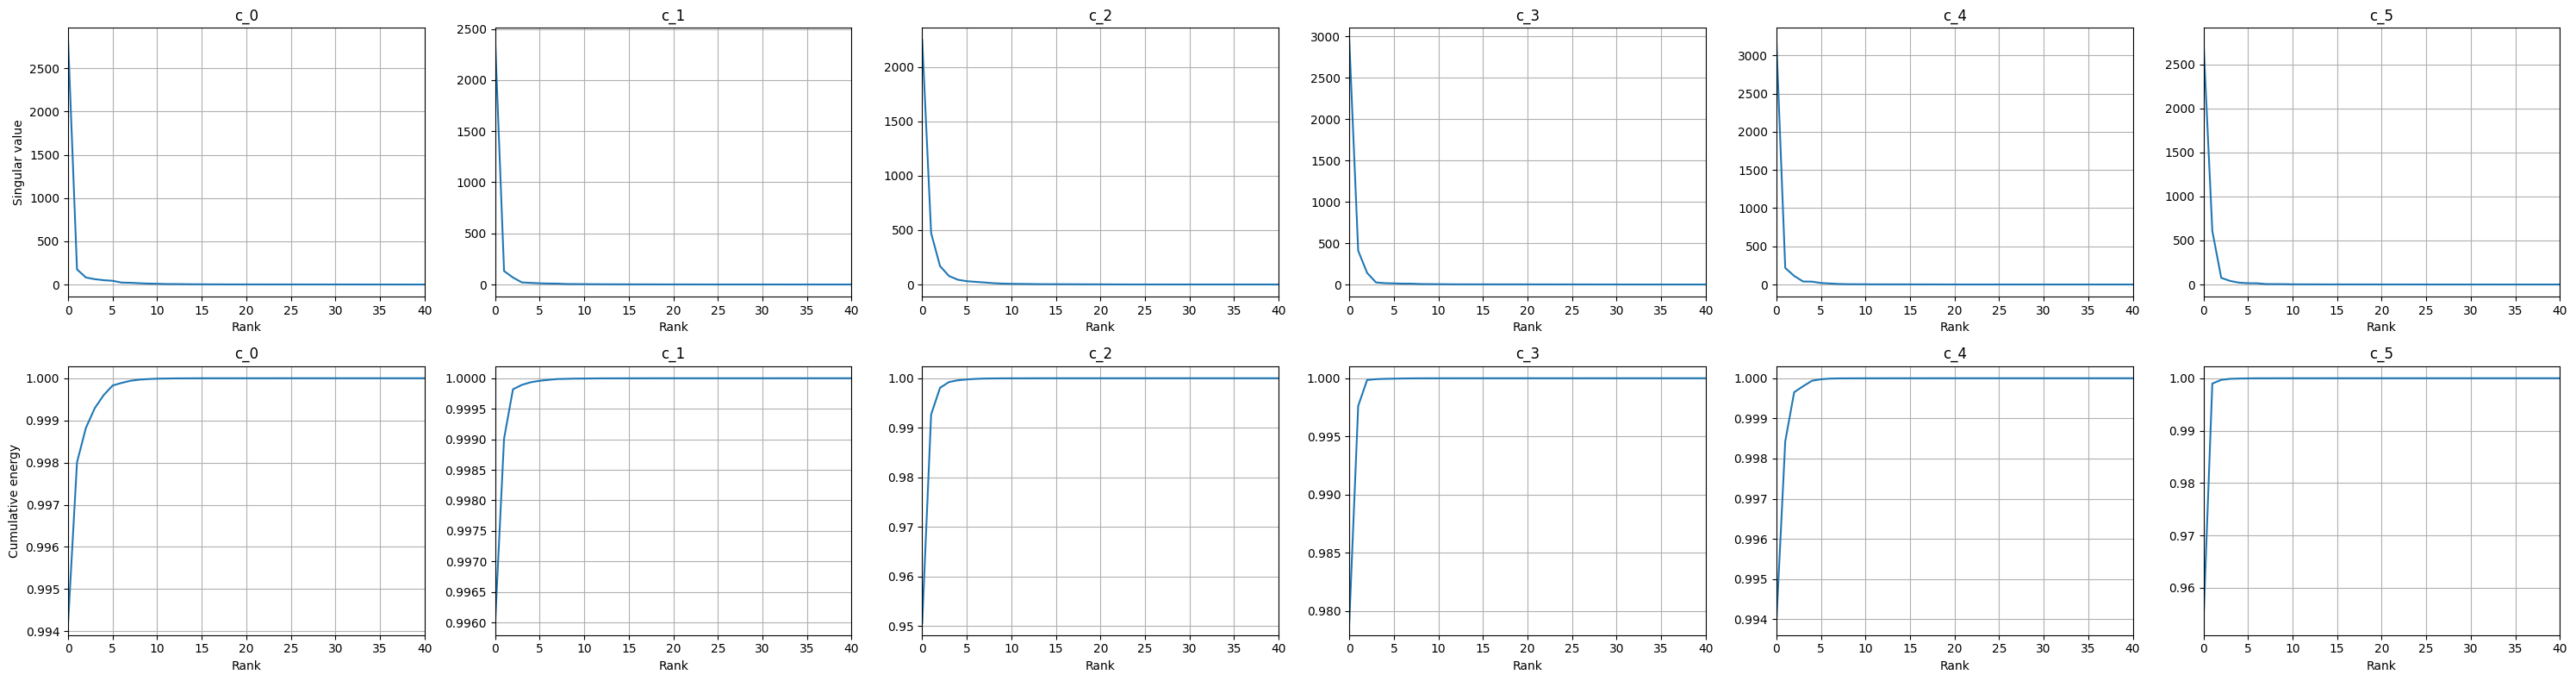

In [5]:
fig, axs = plt.subplots(2, num_species, figsize=(5 * num_species, 8))

for ii, field in enumerate(var_names):
    axs[0, ii].plot(sing_vals[field])
    axs[0, ii].set_title(f"{field}")
    
    _energy = np.cumsum(sing_vals[field]**2) / np.sum(sing_vals[field]**2)
    axs[1, ii].plot(_energy)
    axs[1, ii].set_title(f"{field}")

    if ii == 0:
        axs[0, ii].set_ylabel("Singular value")
        axs[1, ii].set_ylabel("Cumulative energy")

for ax in axs.flatten():
    ax.set_xlabel("Rank")
    ax.set_xlim(0, 40)
    ax.grid()

plt.tight_layout()
plt.show()


### Rank selection

For each species we retain the minimum rank $r_i$ such that the cumulative energy exceeds `retained_energy` (99.99%). The total latent dimension is $R = \sum_i r_i$, with cumulative slice indices stored in `Nmodes`.

In [6]:
retained_energy = 0.9999

ranks = []
for field in var_names:
    _energy = np.cumsum(sing_vals[field]**2) / np.sum(sing_vals[field]**2)
    ranks.append(np.argmax(_energy >= retained_energy))
    print(f"Selected rank {ranks[-1]} for {field} with {retained_energy*100}% energy")

Nmodes = np.concatenate([[0], np.cumsum(ranks)])
print(Nmodes)

Selected rank 7 for c_0 with 99.99% energy
Selected rank 4 for c_1 with 99.99% energy
Selected rank 7 for c_2 with 99.99% energy
Selected rank 3 for c_3 with 99.99% energy
Selected rank 4 for c_4 with 99.99% energy
Selected rank 4 for c_5 with 99.99% energy
[ 0  7 11 18 21 25 29]


### Spatial POD modes

We visualize the leading spatial modes for each species on the computational mesh.

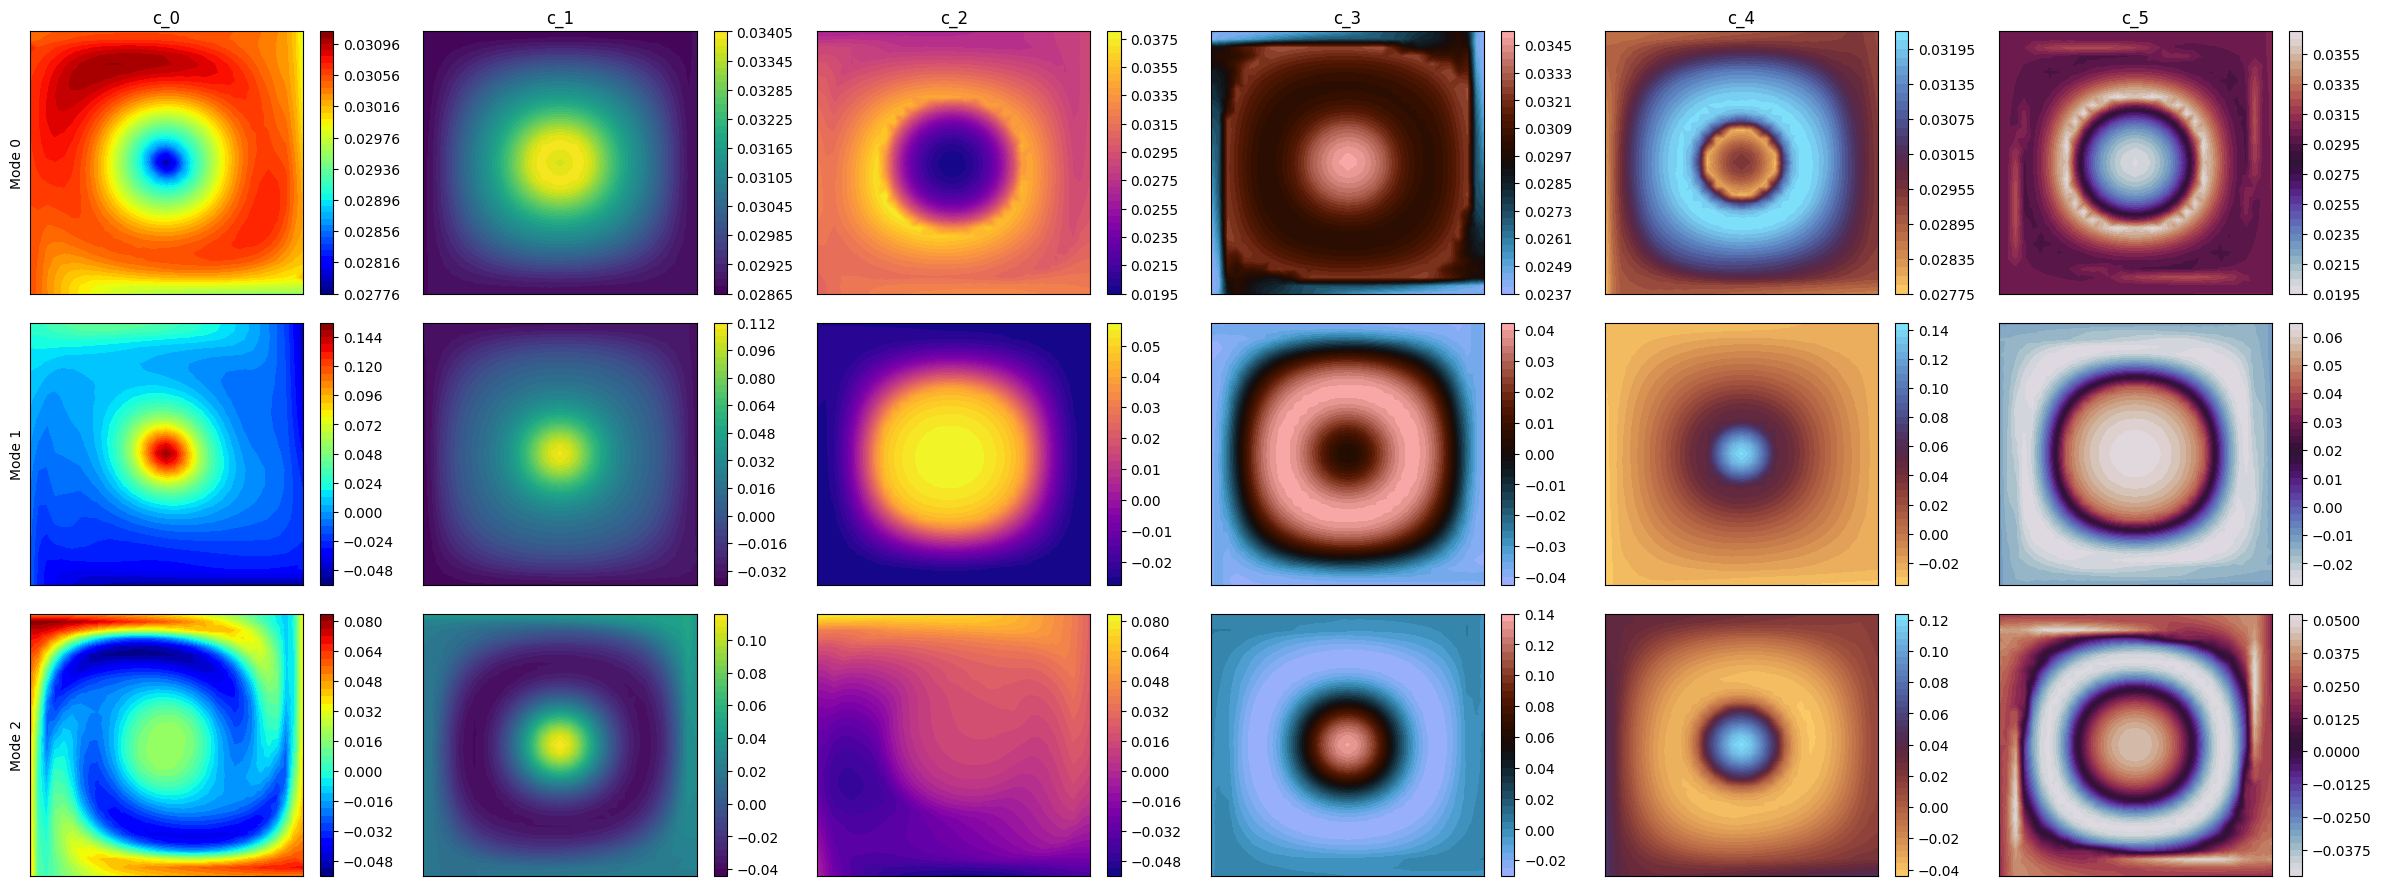

In [7]:
modes_to_plot = np.arange(3)

nrows = len(modes_to_plot)
ncols = len(var_names)

fig, axs = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))

for ii, field in enumerate(var_names):
    for jj, rr in enumerate(modes_to_plot):
        c = plotter.plot(axs[jj, ii], modes[field][:, rr], levels=40, cmap=cmaps[ii])
        fig.colorbar(c, ax=axs[jj, ii])
        
        if jj == 0:
            axs[jj, ii].set_title(f"{field}")
            
        if ii == 0:
            axs[jj, ii].set_ylabel(f"Mode {rr}")

plt.tight_layout()
plt.show()


### POD coefficients

The POD coefficients are obtained by Galerkin projection of the normalized snapshots onto the truncated basis. Coefficients from all species are concatenated along the last axis into a single latent vector $\mathbf{a}(t) \in \mathbb{R}^R$ for each parameter case and time step.

In [8]:
pod_coeffs = {
    'train': {},
    'valid': {},
    'test': {}
}

idx_split = {
    'train': train_idx,
    'valid': val_idx,
    'test': test_idx
}

for key in idx_split:

    pod_coeffs[key] = np.zeros((len(idx_split[key]), Nt, Nmodes[-1]))

    for field_i, field in enumerate(var_names):
        _coeffs = (modes[field][:, :ranks[field_i]].T @ hf_snaps[field][idx_split[key]].reshape(-1, Nh).T).T.reshape(len(idx_split[key]), Nt, ranks[field_i])

        _idx_pod = np.arange(Nmodes[field_i], Nmodes[field_i+1])
        pod_coeffs[key][:, :, _idx_pod] = _coeffs

### POD truncation error (baseline)

Before training SHRED, we quantify the **POD reconstruction error** in normalized HF space:

$$\varepsilon_{\mathrm{POD}} = \frac{\|\mathbf{u} - \mathbf{U}_r \mathbf{U}_r^\top \mathbf{u}\|}{\|\mathbf{u}\|}.$$

This is the best achievable error when the latent representation is exact; SHRED must perform at least this well after decoding.

train
valid
test


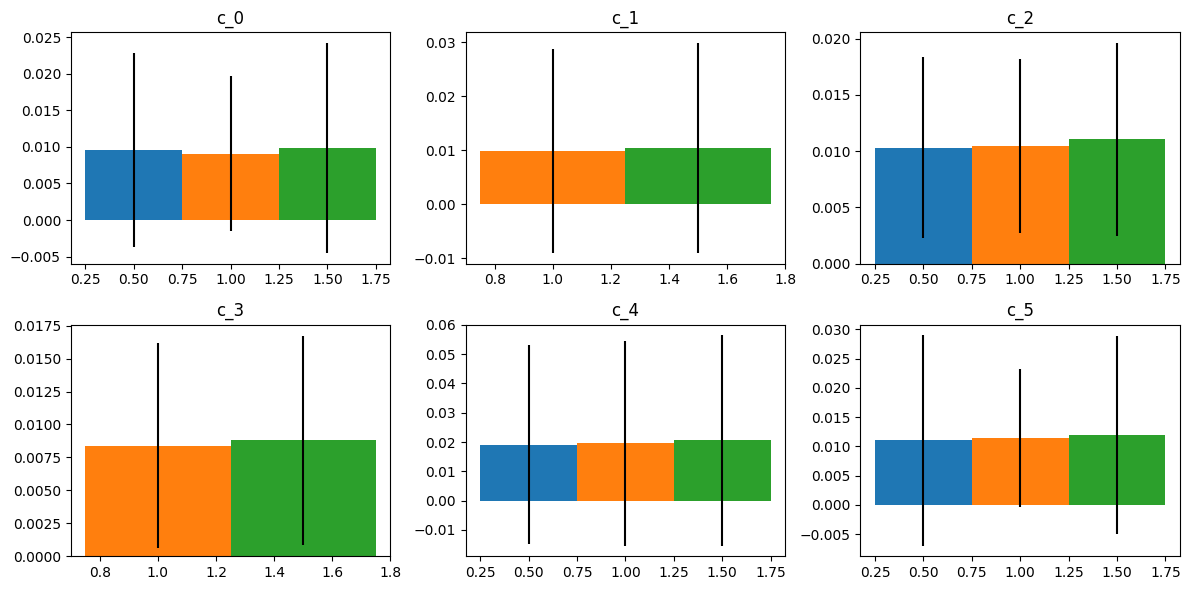

In [9]:
pod_errors = {
    key: np.zeros((len(idx_split[key]), Nt, num_species)) for key in idx_split
}

for key in idx_split:
    print(key)
    for field_i, field in enumerate(var_names):
        _coeff = pod_coeffs[key][:, :, Nmodes[field_i]:Nmodes[field_i+1]]
        _recon = (modes[field][:, :ranks[field_i]] @ _coeff.reshape(-1, ranks[field_i]).T).T.reshape(len(idx_split[key]), Nt, Nh)
        for kk in range(len(idx_split[key])):
            pod_errors[key][kk, :, field_i] = np.linalg.norm(hf_snaps[field][idx_split[key][kk]] - _recon[kk], axis=-1) / np.linalg.norm(hf_snaps[field][idx_split[key][kk]], axis=-1)

nrows = 2
ncols = num_species // nrows
fig, axs = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))

for ii, ax in enumerate(axs.flatten()):
    for jj, key in enumerate(idx_split):
        pos = 0.5 * jj + 0.5
        ax.bar(pos, np.mean(pod_errors[key][:, :, ii]), yerr=np.std(pod_errors[key][:, :, ii]), width=0.5)
    ax.set_title(var_names[ii])

plt.tight_layout()
plt.show()


### Scale POD coefficients

Each POD mode is scaled independently to $[0, 1]$ (`MinMaxScaler`, one min/max per mode) using training coefficients. SHRED is trained to predict these scaled coefficients; `pod_scaler.inverse_transform` is applied before decoding.

In [10]:
pod_scaler = MinMaxScaler()
pod_scaler.fit(pod_coeffs['train'].reshape(-1, pod_coeffs['train'].shape[2]))

for key in pod_coeffs:
    pod_coeffs[key] = pod_scaler.transform(pod_coeffs[key].reshape(-1, pod_coeffs[key].shape[2])).reshape(pod_coeffs[key].shape)

## Baseline SHRED

In this section we use **Shallow Recurrent Decoders (SHRED)** to map a short history of sparse spatial measurements to the full POD coefficient vector.

Unlike a pure state-estimation setup with sensors on a single field, we allow measurements on **multiple species** (here $c_0$, $c_3$, and $c_5$). Sensor locations are encoded in a stacked global index space of size $6 \, N_h$, and decoded back to $(\text{species}, \text{node})$ via integer division and modulo by $N_h$.

### Create measurements

For each of `n_configurations` random sensor layouts we:
1. Draw `num_sensors` locations from the admissible stacked index set (species 0, 3, and 5 only).
2. Extract the corresponding normalized HF time series at those nodes.
3. Scale each sensor channel to $[0, 1]$ and add Gaussian noise.

The plot below shows, for each species, the mesh with sensor locations coloured by configuration.

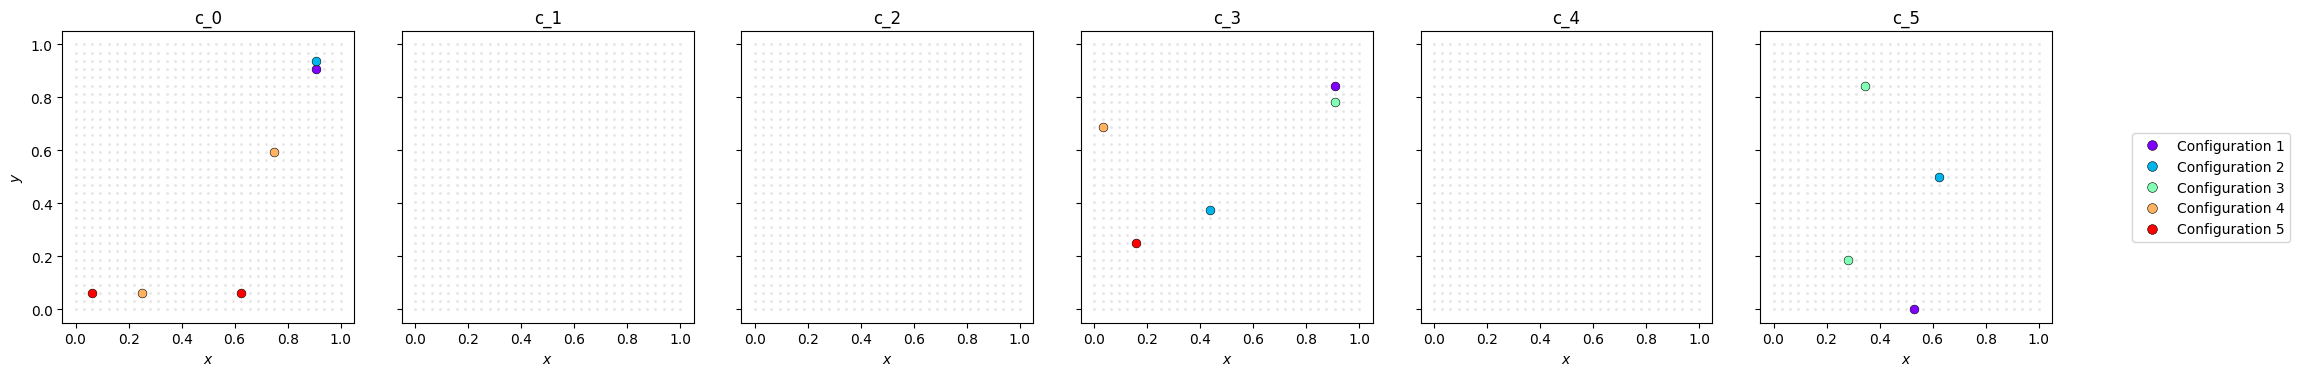

In [11]:
measured_field_i = [0, 3, 5]
admissable_space_idx = np.concatenate(
    [np.arange(field_i * Nh, (field_i + 1) * Nh) for field_i in measured_field_i]
)

n_configurations = 5
num_sensors = 3

np.random.seed(8)
idx_sensor_locations = np.zeros((num_sensors, n_configurations), dtype=int)

for kk in range(n_configurations):
    idx_sensor_locations[:, kk] = np.asarray(
        np.random.choice(admissable_space_idx, size=num_sensors, replace=False), dtype=int
    )

sensor_field_idx = idx_sensor_locations // Nh
sensor_node_idx = idx_sensor_locations % Nh


def extract_sensor_measurements(global_idx, key):
    """Extract sensor time series from stacked global dof indices."""
    out = np.empty((len(idx_split[key]), Nt, len(global_idx)))
    for s, gidx in enumerate(global_idx):
        field_i = gidx // Nh
        node_i = gidx % Nh
        out[..., s] = hf_snaps[var_names[field_i]][idx_split[key]][:, :, node_i]
    return out


measurements = [
    {key: extract_sensor_measurements(idx_sensor_locations[:, kk], key) for key in ['train', 'valid', 'test']}
    for kk in range(n_configurations)
]

meas_scaler = [MinMaxScaler() for kk in range(n_configurations)]
for kk in range(n_configurations):
    meas_scaler[kk].fit(measurements[kk]['train'].reshape(-1, num_sensors))

noise_value = 0.01
scaled_noisy_measurements = [{
    key: meas_scaler[kk].transform(measurements[kk][key].reshape(-1, num_sensors)).reshape(measurements[kk][key].shape)
         + np.random.normal(scale=noise_value, size=measurements[kk][key].shape)
    for key in ['train', 'valid', 'test']
} for kk in range(n_configurations)]

from matplotlib import cm
from matplotlib.lines import Line2D

fig, axs = plt.subplots(1, num_species, figsize=(3.5 * num_species, 3.5), sharex=True, sharey=True)
if num_species == 1:
    axs = np.array([axs])

colors = cm.rainbow(np.linspace(0, 1, n_configurations))

for sp in range(num_species):
    axs[sp].scatter(nodes[:, 0], nodes[:, 1], c='0.9', s=1, rasterized=True)
    axs[sp].set_aspect('equal')
    axs[sp].set_title(var_names[sp])
    axs[sp].set_xlabel('$x$')
    if sp == 0:
        axs[sp].set_ylabel('$y$')

for kk in range(n_configurations):
    for ss in range(num_sensors):
        sp = sensor_field_idx[ss, kk]
        node = sensor_node_idx[ss, kk]
        axs[sp].scatter(
            nodes[node, 0], nodes[node, 1],
            color=colors[kk], s=40, edgecolors='k', linewidths=0.4, zorder=3,
        )

legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[kk], markeredgecolor='k',
           markeredgewidth=0.4, markersize=7, label=f'Configuration {kk + 1}')
    for kk in range(n_configurations)
]
fig.legend(handles=legend_handles, loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()


### Prepare data for SHRED

We build lagged input windows (`lags = 40`) from the scaled noisy sensor trajectories and pair them with the scaled POD coefficients at the same time index. Each sensor configuration defines a separate SHRED model trained on the same output targets.

In [12]:
import sys
sys.path.append('../../../')

from shred.processdata import Padding, TimeSeriesDataset
import torch

# GPU
device = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')

lags = 40

# Input Data
train_data_in = [Padding(torch.from_numpy(scaled_noisy_measurements[kk]['train']), lags).to(device) for kk in range(n_configurations)]
valid_data_in = [Padding(torch.from_numpy(scaled_noisy_measurements[kk]['valid']), lags).to(device) for kk in range(n_configurations)]
test_data_in  = [Padding(torch.from_numpy(scaled_noisy_measurements[kk]['test']), lags).to(device)  for kk in range(n_configurations)]

# Output Data
train_data_out = Padding(torch.from_numpy(pod_coeffs['train']), 1).squeeze(1).to(device)
valid_data_out = Padding(torch.from_numpy(pod_coeffs['valid']), 1).squeeze(1).to(device)
test_data_out  = Padding(torch.from_numpy(pod_coeffs['test']), 1).squeeze(1).to(device)

# Create Dataset for SHRED training
train_dataset = [TimeSeriesDataset(train_data_in[kk], train_data_out) for kk in range(n_configurations)]
valid_dataset = [TimeSeriesDataset(valid_data_in[kk], valid_data_out) for kk in range(n_configurations)]
test_dataset  = [TimeSeriesDataset(test_data_in[kk],  test_data_out)  for kk in range(n_configurations)]

### SHRED training

One SHRED network is trained per sensor configuration. Each model maps $(\text{lag} \times n_{\mathrm{sensors}})$ inputs to the $R$-dimensional POD coefficient vector. Training uses early stopping on the validation set.

In [13]:
measured_fields_tag = '_'.join(var_names[i] for i in measured_field_i)

from shred.models import SHRED, fit
import os

path_shred = './Results/SHRED/'
os.makedirs(path_shred, exist_ok=True)

train_net = False

shred = list()
for kk in range(n_configurations):
    
    shred.append(SHRED( num_sensors, Nmodes[-1], 
                        hidden_size = 64, hidden_layers = 2, decoder_sizes = [350, 400], dropout = 0.1).to(device))

    if train_net:
        print('Training SHRED - configuration '+str(kk+1)+'/'+str(n_configurations))

        fitting_errors = fit(   shred[kk], train_dataset[kk], valid_dataset[kk], 
                                batch_size = 64, epochs = 500, lr = 1e-3, verbose = True, patience = 30)

        shred[kk].freeze()

        torch.save(shred[kk].state_dict(), path_shred+'baselineSHRED_trained_config'+str(kk)+'_measuring_'+str(num_sensors)+'sens_'+measured_fields_tag+'.shred')
        print(' ')
    else:
        shred[kk].load_state_dict(torch.load(path_shred+'baselineSHRED_trained_config'+str(kk)+'_measuring_'+str(num_sensors)+'sens_'+measured_fields_tag+'.shred',
                                             map_location=device))
        shred[kk].freeze()

### Testing on POD coefficients

We evaluate SHRED on the test set and aggregate predictions across sensor configurations (mean, standard error, and covariance in coefficient space). Errors are reported on the **scaled** POD coefficients.

In [14]:
pred_pod_hat = torch.stack([shred[kk](test_data_in[kk]) for kk in range(n_configurations)], dim=0)

pred_pod = {
    'mean': pred_pod_hat.mean(axis=0),
    'std':  pred_pod_hat.std(axis=0) / np.sqrt(n_configurations),
    'cov': torch.stack([torch.cov(pred_pod_hat[:, i, :sum(Nmodes)].T) for i in range(pred_pod_hat.shape[1])]) / n_configurations 
}

# The test data are independent on the configurations of the sensors
from shred.processdata import num2p, mre
print("Mean relative SHRED prediction error on POD coeffs: %s." % num2p(mre(test_data_out,
                                                                            pred_pod['mean']).detach().item()))
print("Std  relative SHRED prediction error on POD coeffs: %s." % num2p((pred_pod['std'].pow(2).sum(axis = -1).sqrt() / (test_data_out).pow(2).sum(axis = -1).sqrt()).mean().detach().item()))

Mean relative SHRED prediction error on POD coeffs: 2.20%.
Std  relative SHRED prediction error on POD coeffs: 1.54%.


### Reshape SHRED outputs

The raw SHRED output has shape $(N_p^{\mathrm{test}} \cdot N_t,\, R)$. We reshape it to $(N_p^{\mathrm{test}},\, N_t,\, R)$ so that each test parameter case and time step can be accessed directly, with mode blocks aligned to the `Nmodes` slice indices.

In [15]:
reshaped_test_out = test_data_out.cpu().detach().numpy().reshape(len(idx_split['test']), Nt, Nmodes[-1])

reshaped_POD_pred_out = {
    'mean': pred_pod['mean'].cpu().detach().numpy().reshape(len(idx_split['test']), Nt, Nmodes[-1]),
    'std':  pred_pod['std'].cpu().detach().numpy().reshape(len(idx_split['test']), Nt, Nmodes[-1]),
    'cov':  pred_pod['cov'][:, :sum(Nmodes), :sum(Nmodes)].cpu().detach().numpy().reshape(len(idx_split['test']), Nt, Nmodes[-1], Nmodes[-1]),
}

### Error per POD mode

We plot the mean relative error for each scaled POD coefficient, with vertical dashed lines separating species blocks. Error bars reflect the uncertainty propagated from the ensemble of sensor configurations.

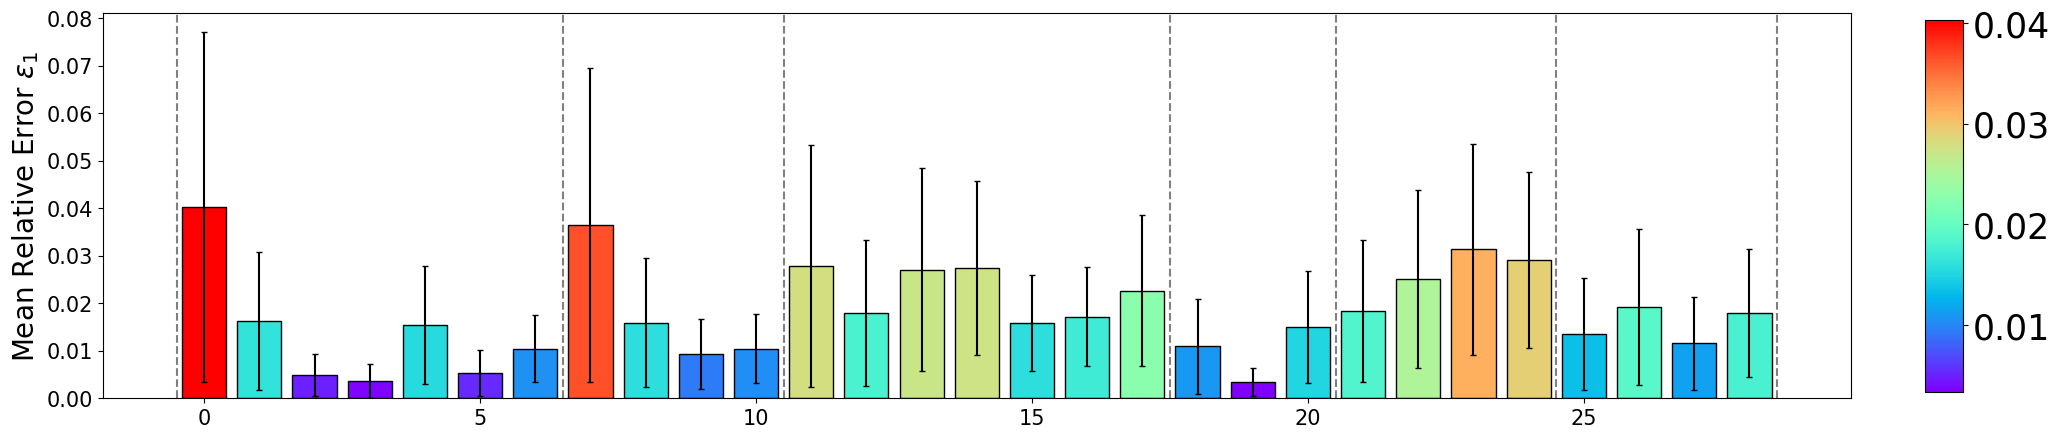

In [16]:
from matplotlib.colors import Normalize

# errors_pod_coeffs already computed
errors_pod_coeffs = [np.mean(np.abs(reshaped_test_out[:, :, pp] - reshaped_POD_pred_out['mean'][:, :, pp]), axis=(0,1)) / np.mean(np.abs(reshaped_test_out[:, :, pp]))
                     for pp in range(reshaped_test_out.shape[2])]
err_std_pod_coeffs = [np.mean(reshaped_POD_pred_out['std'][:, :, pp], axis=(0,1)) / np.mean(np.abs(reshaped_test_out[:, :, pp]))
                     for pp in range(reshaped_test_out.shape[2])]

fig, axs = plt.subplots(1, 1, figsize=(24, 5))

# Normalize error values to [0,1] for colormap mapping
norm = Normalize(vmin=min(errors_pod_coeffs), vmax=max(errors_pod_coeffs))
cmap = cm.rainbow  # choose your favorite colormap here
colors = cmap(norm(errors_pod_coeffs))

# Plot bars with colors
bars = axs.bar(np.arange(Nmodes[-1]), errors_pod_coeffs, 
               yerr = err_std_pod_coeffs, ecolor='k', capsize=2,
               edgecolor='k',
               color=colors)

# Vertical lines for Nmodes grouping
for pp in range(len(Nmodes)):
    axs.axvline(x=Nmodes[pp]-0.5, color='gray', linestyle='--')

axs.tick_params(axis='both', which='major', labelsize=15)
axs.set_ylabel(r'Mean Relative Error $\varepsilon_1$', fontsize=20)

# Add colorbar for reference
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axs, fraction=0.02, pad=0.04, aspect=10)
cbar.ax.tick_params(labelsize=25)

### POD coefficient trajectories

For a random subset of test parameter cases we compare the ground-truth scaled POD coefficients with the SHRED prediction (mean $\pm 2\sigma$ across configurations).

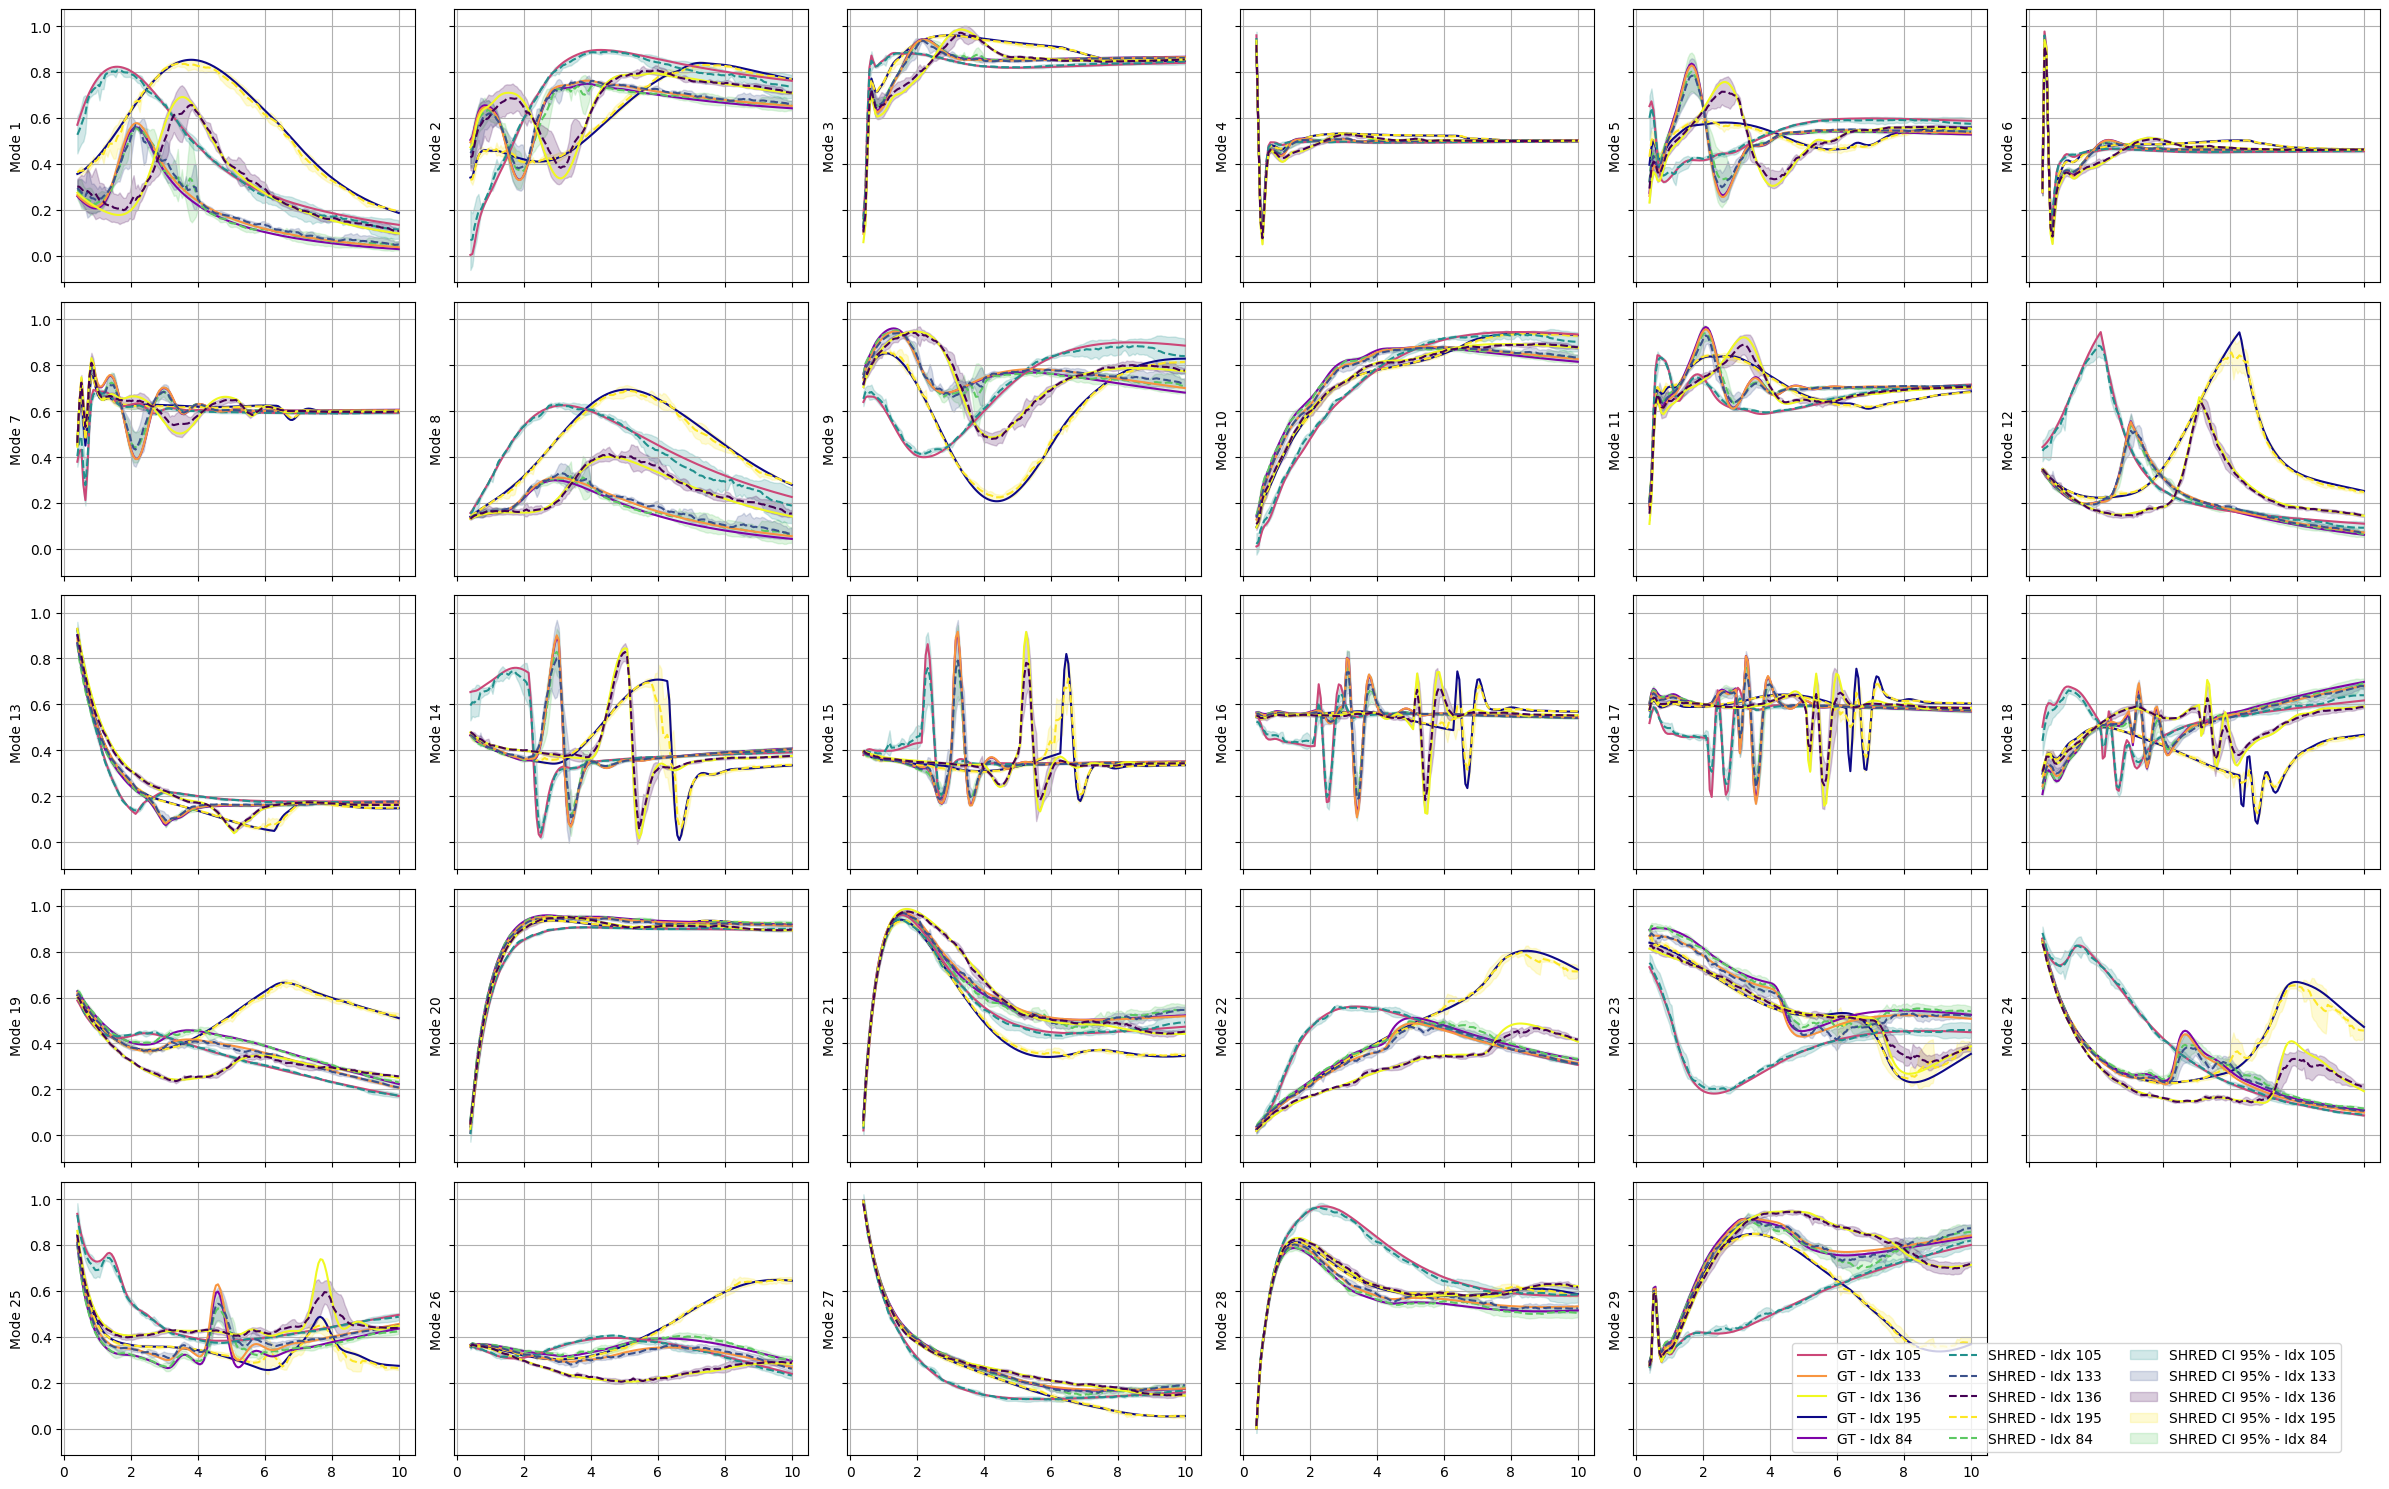

In [17]:
np.random.seed(8)
params_to_plot = np.random.randint(0, len(idx_split['test']), size=5)

nrows = 5
ncols = Nmodes[-1] // nrows + 1

fig, axs = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), sharex=True, sharey=True)
axs = axs.flatten()

colors_gt = cm.plasma(np.linspace(0,1,len(params_to_plot)))
colors_pred = cm.viridis_r(np.linspace(0,1,len(params_to_plot)))

for rr in range(Nmodes[-1]):

    for ll, param in enumerate(params_to_plot):
        axs[rr].plot(times, reshaped_test_out[param, :, rr], color=colors_gt[ll], label='GT - Idx '+str(param))
        axs[rr].plot(times, reshaped_POD_pred_out['mean'][param, :, rr], '--', color=colors_pred[ll], label='SHRED - Idx '+str(param))
        axs[rr].fill_between(times, reshaped_POD_pred_out['mean'][param, :, rr] - 2 * reshaped_POD_pred_out['std'][param, :, rr], reshaped_POD_pred_out['mean'][param, :, rr] + 2 * reshaped_POD_pred_out['std'][param, :, rr], color=colors_pred[ll], alpha=0.2, label='SHRED CI 95% - Idx '+str(param))
        axs[rr].set_ylabel(f'Mode {rr+1}')
    axs[rr].grid()

for rr in range(Nmodes[-1], axs.shape[0]):
    axs[rr].axis('off')
_lin, _lab = axs[0].get_legend_handles_labels() 
_argsort = np.argsort(_lab)
fig.legend(np.array(_lin)[_argsort], np.array(_lab)[_argsort], loc=(0.75, 0.025), ncols=3)

plt.tight_layout()
plt.show()


### Decoding to high-dimensional space

Predicted POD coefficients are unscaled and projected back onto the spatial bases:

$$\hat{\mathbf{u}}_i(\mathbf{x}, t) = \mathbf{U}_i \, \hat{\mathbf{a}}_i(t).$$

Reconstruction errors are computed in **normalized HF space**, consistent with the preprocessing step.

In [18]:
baseline_shred_errors = np.zeros((len(idx_split['test']), Nt, num_species))

unscaled_pod_hat = pod_scaler.inverse_transform(reshaped_POD_pred_out['mean'].reshape(-1, Nmodes[-1])).reshape(len(idx_split['test']), Nt, Nmodes[-1])

for field_i, field in enumerate(var_names):

    _idx_pod = np.arange(Nmodes[field_i], Nmodes[field_i+1])
    _pod_hat = unscaled_pod_hat[:, :, _idx_pod]

    for pp in range(len(idx_split['test'])):
        _recon = (modes[field][:, :ranks[field_i]] @ _pod_hat[pp].T).T
        baseline_shred_errors[pp, :, field_i] = np.linalg.norm(hf_snaps[field][idx_split['test'][pp]] - _recon, axis=-1) / np.linalg.norm(hf_snaps[field][idx_split['test'][pp]], axis=-1)

### Compare SHRED and POD reconstruction errors

We compare the mean relative HF reconstruction error of **baseline SHRED** (decode predicted POD coefficients) against the **POD truncation baseline** (project the ground-truth field onto the retained basis). Both metrics are averaged over test cases and time, reported per species.

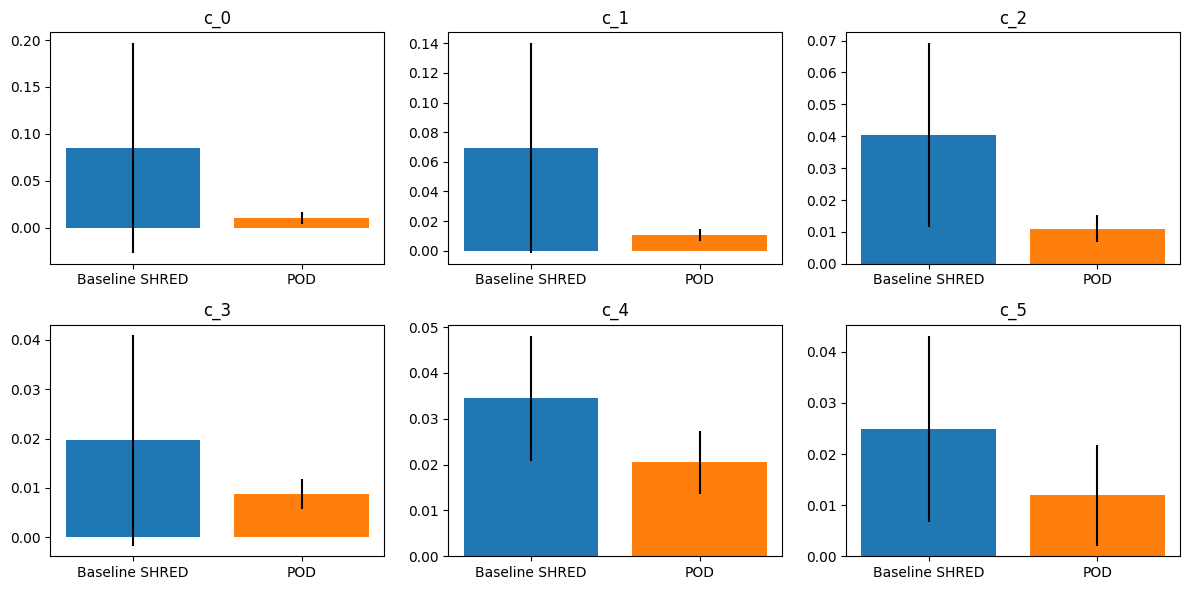

In [19]:
nrows = 2
ncols = num_species // nrows
fig, axs = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
axs = axs.flatten()

for ii, ax in enumerate(axs):
    ax.bar(0, baseline_shred_errors[..., ii].mean(), 
        yerr=baseline_shred_errors[..., ii].mean(axis=1).std()
        )
    ax.bar(1, pod_errors['test'][..., ii].mean(), 
        yerr=pod_errors['test'][..., ii].mean(axis=1).std()
        )

    ax.set_title(var_names[ii])
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Baseline SHRED', 'POD'])

plt.tight_layout()
plt.show()

# nrows = 2
# ncols = num_species // nrows
# fig, axs = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
# axs = axs.flatten()

# for ii, ax in enumerate(axs):
#     ax.plot(times, baseline_shred_errors[:, :, ii].mean(axis=0))
#     ax.plot(times, pod_errors['test'][:, :, ii].mean(axis=0))

### Spatial snapshot comparison

For one random test case at the final time step, we compare the normalized HF field (FOM), the POD-Galerkin projection, and the SHRED-decoded field side by side for each species.

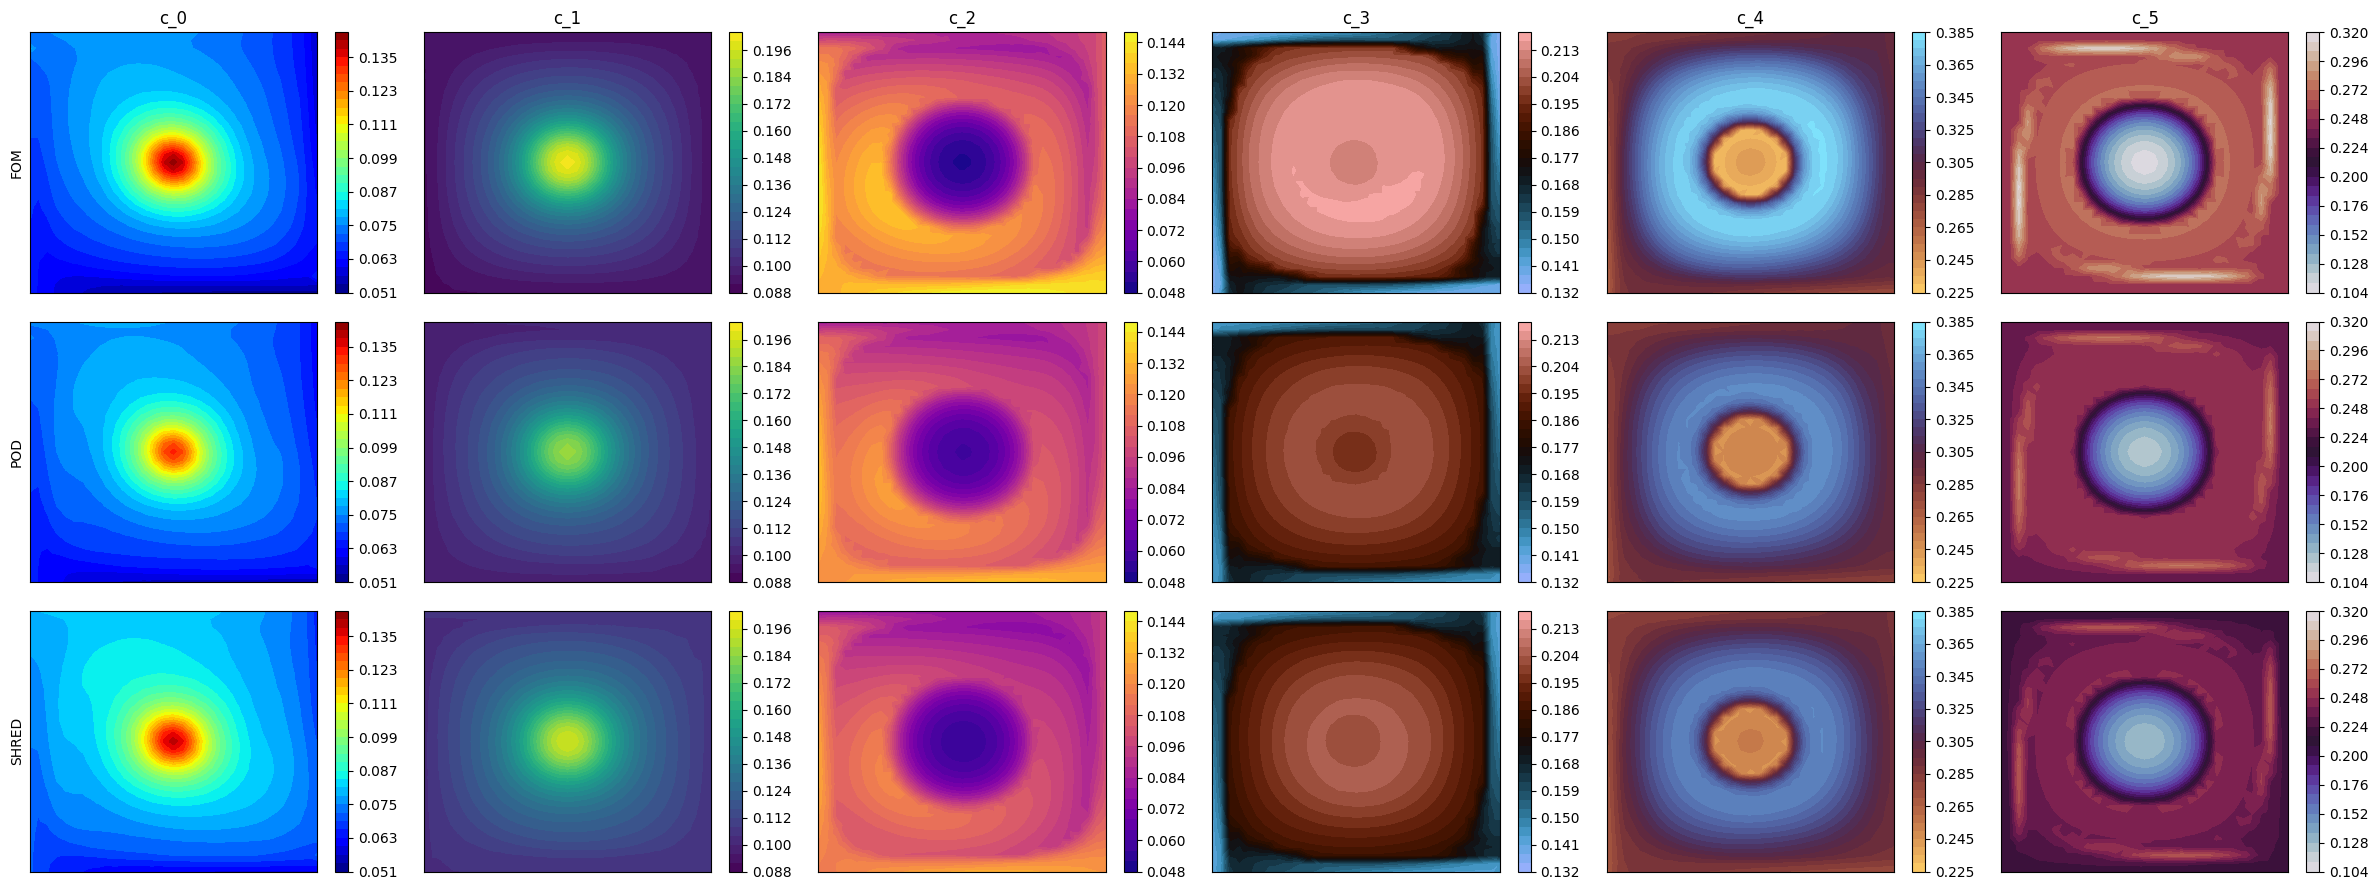

In [20]:
tt = -1
pp = np.random.randint(0, len(idx_split['test']))

nrows = 3
ncols = num_species

fig, axs = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))

for field_i, field in enumerate(var_names):

    _fom = hf_snaps[field][idx_split['test'][pp], tt]

    _idx_pod = np.arange(Nmodes[field_i], Nmodes[field_i+1])
    _pod_recon = modes[field][:, :ranks[field_i]] @ (modes[field][:, :ranks[field_i]].T @ _fom)
    _shred_recon = modes[field][:, :ranks[field_i]] @ unscaled_pod_hat[pp, tt, _idx_pod]

    c = plotter.plot(axs[0, field_i], _fom, levels=30, cmap=cmaps[field_i])
    fig.colorbar(c, ax=axs[0, field_i])
    levels = np.linspace(c.get_clim()[0] * 0.9, c.get_clim()[1] * 1.1, 30)

    plotter.plot(axs[1, field_i], _pod_recon, levels=levels, cmap=cmaps[field_i])
    fig.colorbar(c, ax=axs[1, field_i])

    plotter.plot(axs[2, field_i], _shred_recon, levels=levels, cmap=cmaps[field_i])
    fig.colorbar(c, ax=axs[2, field_i])

    if field_i == 0:
        axs[0, field_i].set_ylabel(f'FOM')
        axs[1, field_i].set_ylabel(f'POD')
        axs[2, field_i].set_ylabel(f'SHRED')

    axs[0, field_i].set_title(f'{field}')

plt.tight_layout()
plt.show()

## Multi-fidelity SHRED between LF and HF

The baseline SHRED above uses sparse HF sensors as input. In this section we will replace (or augment) those inputs with **low-fidelity trajectories** $\mathbf{u}_{\mathrm{LF}}(t; \boldsymbol{\mu}) \in \mathbb{R}^6$ from the spatially averaged ODE model, while still targeting the same HF POD coefficients.

The LF data are already loaded (`lf`, shape $(N_s, N_t, 6)$) and aligned with the HF time subsampling. Next steps:
1. Scale LF trajectories (train fit).
2. Build lagged input windows from LF (and optionally HF sensors).
3. Train multi-fidelity SHRED and compare against the baseline.

In [21]:
num_lf_sensors = 3

np.random.seed(8)
idx_lf_sensor_locations = np.zeros((num_lf_sensors, n_configurations), dtype=int)

for kk in range(n_configurations):
    idx_lf_sensor_locations[:, kk] = np.asarray(
        np.random.choice(num_species, size=num_lf_sensors, replace=False), dtype=int
    )

lf_measurements = {
    key: np.zeros((len(idx_split[key]), Nt, num_lf_sensors)) for key in idx_split
}

for key in idx_split:
    for kk in range(n_configurations):
        lf_measurements[key] = lf[idx_split[key]][:, :, idx_lf_sensor_locations[:, kk]]

lf_meas_scaler = [MinMaxScaler() for kk in range(n_configurations)]
for kk in range(n_configurations):
    lf_meas_scaler[kk].fit(lf_measurements['train'].reshape(-1, num_lf_sensors))

scaled_lf_measurements = [{
    key: lf_meas_scaler[kk].transform(lf_measurements[key].reshape(-1, num_lf_sensors)).reshape(lf_measurements[key].shape)
    for key in idx_split
} for kk in range(n_configurations)]

### Prepare data for SHRED

We build lagged input windows (`lags = 40`) from the scaled noisy sensor trajectories and pair them with the scaled POD coefficients at the same time index. Each sensor configuration defines a separate SHRED model trained on the same output targets.

In [22]:
import sys
sys.path.append('../../../')

from shred.processdata import Padding, TimeSeriesDataset
import torch

# Input Data
train_data_in = [Padding(torch.from_numpy(scaled_lf_measurements[kk]['train']), lags).to(device) for kk in range(n_configurations)]
valid_data_in = [Padding(torch.from_numpy(scaled_lf_measurements[kk]['valid']), lags).to(device) for kk in range(n_configurations)]
test_data_in  = [Padding(torch.from_numpy(scaled_lf_measurements[kk]['test']), lags).to(device)  for kk in range(n_configurations)]

# Output Data
train_data_out = Padding(torch.from_numpy(pod_coeffs['train']), 1).squeeze(1).to(device)
valid_data_out = Padding(torch.from_numpy(pod_coeffs['valid']), 1).squeeze(1).to(device)
test_data_out  = Padding(torch.from_numpy(pod_coeffs['test']), 1).squeeze(1).to(device)

# Create Dataset for SHRED training
mf_train_dataset = [TimeSeriesDataset(train_data_in[kk], train_data_out) for kk in range(n_configurations)]
mf_valid_dataset = [TimeSeriesDataset(valid_data_in[kk], valid_data_out) for kk in range(n_configurations)]
mf_test_dataset  = [TimeSeriesDataset(test_data_in[kk],  test_data_out)  for kk in range(n_configurations)]

### SHRED training

One SHRED network is trained per sensor configuration. Each model maps $(\text{lag} \times n_{\mathrm{LF-sensors}})$ inputs to the $R$-dimensional POD coefficient vector. Training uses early stopping on the validation set.

In [29]:
from shred.models import SHRED, fit

mfshred = list()
mf_training_time = []

for kk in range(n_configurations):
    
    mfshred.append(SHRED( num_lf_sensors, Nmodes[-1], 
                        hidden_size = 64, hidden_layers = 2, decoder_sizes = [350, 400], dropout = 0.1).to(device))

    if train_net:
        _start_time = perf_counter()
        print('Training SHRED - configuration '+str(kk+1)+'/'+str(n_configurations))

        fitting_errors = fit(   mfshred[kk], mf_train_dataset[kk], mf_valid_dataset[kk], batch_size = 64, epochs = 500, lr = 1e-3, verbose = True, patience = 30)

        mfshred[kk].freeze()

        torch.save(mfshred[kk].state_dict(), path_shred+'MFSHRED_trained_config'+str(kk)+'_measuring_'+str(num_lf_sensors)+'.shred')

        _end_time = perf_counter()
        mf_training_time.append(_end_time - _start_time)
    else:
        mfshred[kk].load_state_dict(torch.load(path_shred+'MFSHRED_trained_config'+str(kk)+'_measuring_'+str(num_lf_sensors)+'.shred', map_location=device))

if train_net:
    np.save(path_shred+'mf_training_time.npy', mf_training_time)
else:
    mf_training_time = np.load(path_shred+'mf_training_time.npy')

computational_times['MF-SHRED'] = {
    'Training': mf_training_time
}

### Testing on POD coefficients

We evaluate SHRED on the test set and aggregate predictions across sensor configurations (mean, standard error, and covariance in coefficient space). Errors are reported on the **scaled** POD coefficients.

In [30]:
_start_time = perf_counter()

mf_pred_pod_hat = torch.stack([mfshred[kk](test_data_in[kk]) for kk in range(n_configurations)], dim=0)

mf_pred_pod = {
    'mean': mf_pred_pod_hat.mean(axis=0),
    'std':  mf_pred_pod_hat.std(axis=0) / np.sqrt(n_configurations),
    'cov': torch.stack([torch.cov(mf_pred_pod_hat[:, i, :sum(Nmodes)].T) for i in range(mf_pred_pod_hat.shape[1])]) / n_configurations 
}
computational_times['MF-SHRED']['Prediction'] = perf_counter() - _start_time

# The test data are independent on the configurations of the sensors
from shred.processdata import num2p, mre
print("Mean relative SHRED prediction error on POD coeffs: %s." % num2p(mre(test_data_out,
                                                                            mf_pred_pod['mean']).detach().item()))
print("Std  relative SHRED prediction error on POD coeffs: %s." % num2p((mf_pred_pod['std'].pow(2).sum(axis = -1).sqrt() / (test_data_out).pow(2).sum(axis = -1).sqrt()).mean().detach().item()))

Mean relative SHRED prediction error on POD coeffs: 1.75%.
Std  relative SHRED prediction error on POD coeffs: 1.32%.


### Per-configuration POD coefficient errors

Check: mean relative error (MRE) of each MF-SHRED sensor configuration against the test-set ground-truth POD coefficients, compared with the ensemble-mean prediction used above.

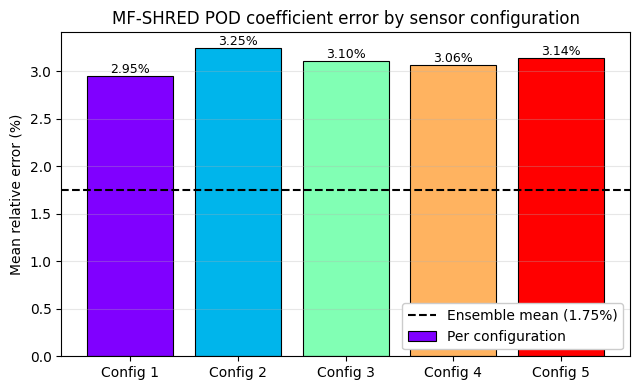

In [81]:
from shred.processdata import num2p, mre

config_mre = np.array([
    mre(test_data_out, mf_pred_pod_hat[kk]).detach().item()
    for kk in range(n_configurations)
])
ensemble_mre = mre(test_data_out, mf_pred_pod['mean']).detach().item()

fig, ax = plt.subplots(figsize=(6.5, 4))
colors = plt.cm.rainbow(np.linspace(0, 1, n_configurations))
x = np.arange(n_configurations)

bars = ax.bar(
    x,
    config_mre * 100,
    color=colors,
    edgecolor='k',
    linewidth=0.8,
    label='Per configuration',
)
ax.axhline(
    ensemble_mre * 100,
    color='k',
    ls='--',
    lw=1.5,
    label=f'Ensemble mean ({num2p(ensemble_mre)})',
)

ax.set_xticks(x)
ax.set_xticklabels([f'Config {kk + 1}' for kk in range(n_configurations)])
ax.set_ylabel('Mean relative error (%)')
ax.set_title('MF-SHRED POD coefficient error by sensor configuration')
ax.bar_label(bars, labels=[f'{v * 100:.2f}%' for v in config_mre], fontsize=9)
ax.legend(loc='lower right', framealpha=1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Reshape SHRED outputs

The raw SHRED output has shape $(N_p^{\mathrm{test}} \cdot N_t,\, R)$. We reshape it to $(N_p^{\mathrm{test}},\, N_t,\, R)$ so that each test parameter case and time step can be accessed directly, with mode blocks aligned to the `Nmodes` slice indices.

In [31]:
mf_reshaped_test_out = test_data_out.cpu().detach().numpy().reshape(len(idx_split['test']), Nt, Nmodes[-1])

_start_time = perf_counter()
mf_reshaped_POD_pred_out = {
    'mean': mf_pred_pod['mean'].cpu().detach().numpy().reshape(len(idx_split['test']), Nt, Nmodes[-1]),
    'std':  mf_pred_pod['std'].cpu().detach().numpy().reshape(len(idx_split['test']), Nt, Nmodes[-1]),
    'cov':  mf_pred_pod['cov'][:, :sum(Nmodes), :sum(Nmodes)].cpu().detach().numpy().reshape(len(idx_split['test']), Nt, Nmodes[-1], Nmodes[-1]),
}
computational_times['MF-SHRED']['Reshape'] = perf_counter() - _start_time

## Comparison of the two approaches

We compare **baseline SHRED** (sparse HF sensors on $c_0$, $c_3$, $c_5$) against **multi-fidelity SHRED** (LF species trajectories as input). Both models target the same scaled POD coefficients and are evaluated in normalized space.

The comparison covers:
1. Per-mode POD coefficient errors.
2. High-dimensional reconstruction errors after decoding.
3. Spatial snapshot and spatially averaged trajectories for selected test cases.

### POD coefficient errors

Mean relative error per POD mode for baseline and MF SHRED (scaled coefficients). Error bars show the mean uncertainty across sensor configurations.

Overall POD coeff. MRE — Baseline SHRED: 2.20%
Overall POD coeff. MRE — MF SHRED:       1.75%


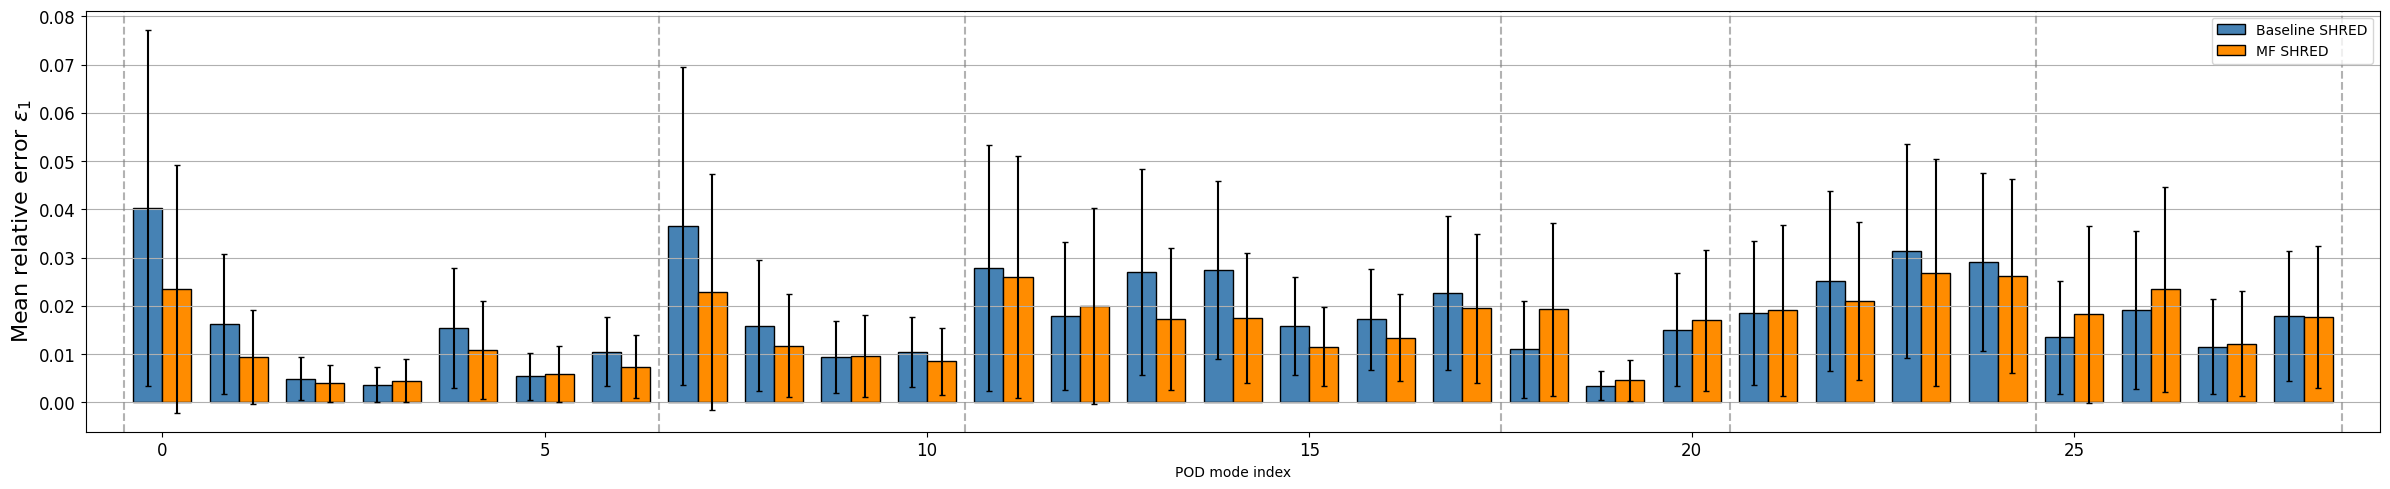

In [32]:
errors_baseline_pod_coeffs = [np.mean(np.abs(reshaped_test_out[:, :, pp] - reshaped_POD_pred_out['mean'][:, :, pp]), axis=(0, 1))
                              / np.mean(np.abs(reshaped_test_out[:, :, pp]))
                              for pp in range(reshaped_test_out.shape[2])]
err_std_baseline_pod_coeffs = [np.mean(reshaped_POD_pred_out['std'][:, :, pp], axis=(0, 1))
                               / np.mean(np.abs(reshaped_test_out[:, :, pp]))
                               for pp in range(reshaped_test_out.shape[2])]

errors_mf_pod_coeffs = [np.mean(np.abs(mf_reshaped_test_out[:, :, pp] - mf_reshaped_POD_pred_out['mean'][:, :, pp]), axis=(0, 1))
                        / np.mean(np.abs(mf_reshaped_test_out[:, :, pp]))
                        for pp in range(mf_reshaped_test_out.shape[2])]
err_std_mf_pod_coeffs = [np.mean(mf_reshaped_POD_pred_out['std'][:, :, pp], axis=(0, 1))
                       / np.mean(np.abs(mf_reshaped_test_out[:, :, pp]))
                       for pp in range(mf_reshaped_test_out.shape[2])]

from shred.processdata import num2p, mre
print('Overall POD coeff. MRE — Baseline SHRED: %s' % num2p(
    mre(torch.from_numpy(reshaped_test_out.reshape(-1, Nmodes[-1])),
        torch.from_numpy(reshaped_POD_pred_out['mean'].reshape(-1, Nmodes[-1]))).item()))
print('Overall POD coeff. MRE — MF SHRED:       %s' % num2p(
    mre(torch.from_numpy(mf_reshaped_test_out.reshape(-1, Nmodes[-1])),
        torch.from_numpy(mf_reshaped_POD_pred_out['mean'].reshape(-1, Nmodes[-1]))).item()))

x = np.arange(Nmodes[-1])
width = 0.38
fig, ax = plt.subplots(1, 1, figsize=(24, 5))

ax.bar(x - width / 2, errors_baseline_pod_coeffs, width,
       yerr=err_std_baseline_pod_coeffs, ecolor='k', capsize=2,
       label='Baseline SHRED', color='steelblue', edgecolor='k')
ax.bar(x + width / 2, errors_mf_pod_coeffs, width,
       yerr=err_std_mf_pod_coeffs, ecolor='k', capsize=2,
       label='MF SHRED', color='darkorange', edgecolor='k')

for pp in range(len(Nmodes)):
    ax.axvline(x=Nmodes[pp] - 0.5, color='gray', linestyle='--', alpha=0.6)

ax.set_ylabel(r'Mean relative error $\varepsilon_1$', fontsize=16)
ax.set_xlabel('POD mode index')
ax.legend(loc='upper right')
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_xlim(-1, Nmodes[-1])
ax.grid(axis='y')
plt.tight_layout()
plt.show()

### High-dimensional reconstruction errors

We decode predicted POD coefficients back to the HF mesh and compute the relative $\ell_2$ error in normalized space. The POD truncation error (projection of the ground truth onto the retained basis) is shown as a reference lower bound.

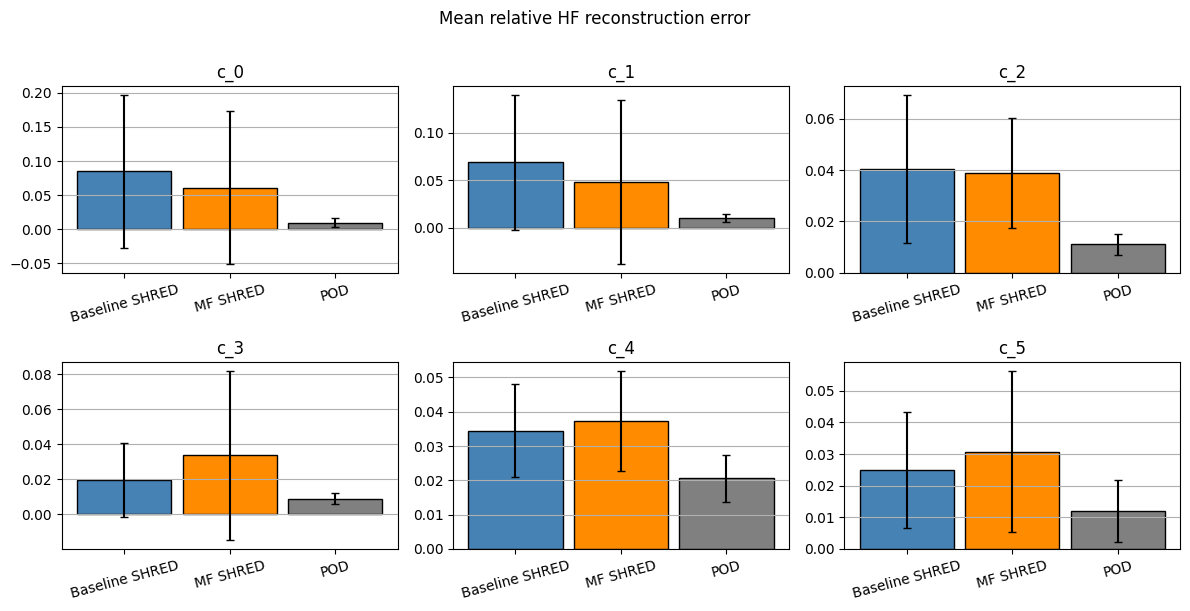

In [34]:
mf_shred_errors = np.zeros((len(idx_split['test']), Nt, num_species))

_start = perf_counter()
unscaled_mf_pod_hat = pod_scaler.inverse_transform(
    mf_reshaped_POD_pred_out['mean'].reshape(-1, Nmodes[-1])
).reshape(len(idx_split['test']), Nt, Nmodes[-1])
computational_times['MF-SHRED']['ScaleBack'] = perf_counter() - _start

for field_i, field in enumerate(var_names):
    _idx_pod = np.arange(Nmodes[field_i], Nmodes[field_i + 1])
    _pod_hat = unscaled_mf_pod_hat[:, :, _idx_pod]

    for pp in range(len(idx_split['test'])):
        _recon = (modes[field][:, :ranks[field_i]] @ _pod_hat[pp].T).T
        mf_shred_errors[pp, :, field_i] = (
            np.linalg.norm(hf_snaps[field][idx_split['test'][pp]] - _recon, axis=-1)
            / np.linalg.norm(hf_snaps[field][idx_split['test'][pp]], axis=-1)
        )

nrows = 2
ncols = num_species // nrows
fig, axs = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
axs = axs.flatten()

bar_labels = ['Baseline SHRED', 'MF SHRED', 'POD']
bar_colors = ['steelblue', 'darkorange', 'gray']
offsets = np.array([-width, 0.0, width]) if False else np.array([-0.28, 0.0, 0.28])

for ii, ax in enumerate(axs):
    means = [
        baseline_shred_errors[..., ii].mean(),
        mf_shred_errors[..., ii].mean(),
        pod_errors['test'][..., ii].mean(),
    ]
    stds = [
        baseline_shred_errors[..., ii].mean(axis=1).std(),
        mf_shred_errors[..., ii].mean(axis=1).std(),
        pod_errors['test'][..., ii].mean(axis=1).std(),
    ]
    ax.bar(offsets, means, width=0.25, yerr=stds, capsize=3,
           color=bar_colors, edgecolor='k', tick_label=bar_labels)
    ax.set_title(var_names[ii])
    ax.tick_params(axis='x', rotation=15)
    ax.grid(axis='y')

fig.suptitle('Mean relative HF reconstruction error', y=1.01)
plt.tight_layout()
plt.show()

Let us compute the necessary time to decode the MF-SHRED

In [35]:
computational_times['MF-SHRED']['Decode'] = []

for field_i, field in enumerate(var_names):
    _idx_pod = np.arange(Nmodes[field_i], Nmodes[field_i + 1])
    _pod_hat = unscaled_mf_pod_hat[:, :, _idx_pod]

    computational_times['MF-SHRED']['Decode'].append([])

    for pp in range(len(idx_split['test'])):
        _start = perf_counter()
        _recon = (modes[field][:, :ranks[field_i]] @ _pod_hat[pp].T).T
        computational_times['MF-SHRED']['Decode'][field_i].append(perf_counter() - _start)

### Spatial snapshot comparison

For one random test parameter at the final time step, we compare the normalized HF field (FOM), the POD-Galerkin projection, and the decoded fields from baseline and MF SHRED.

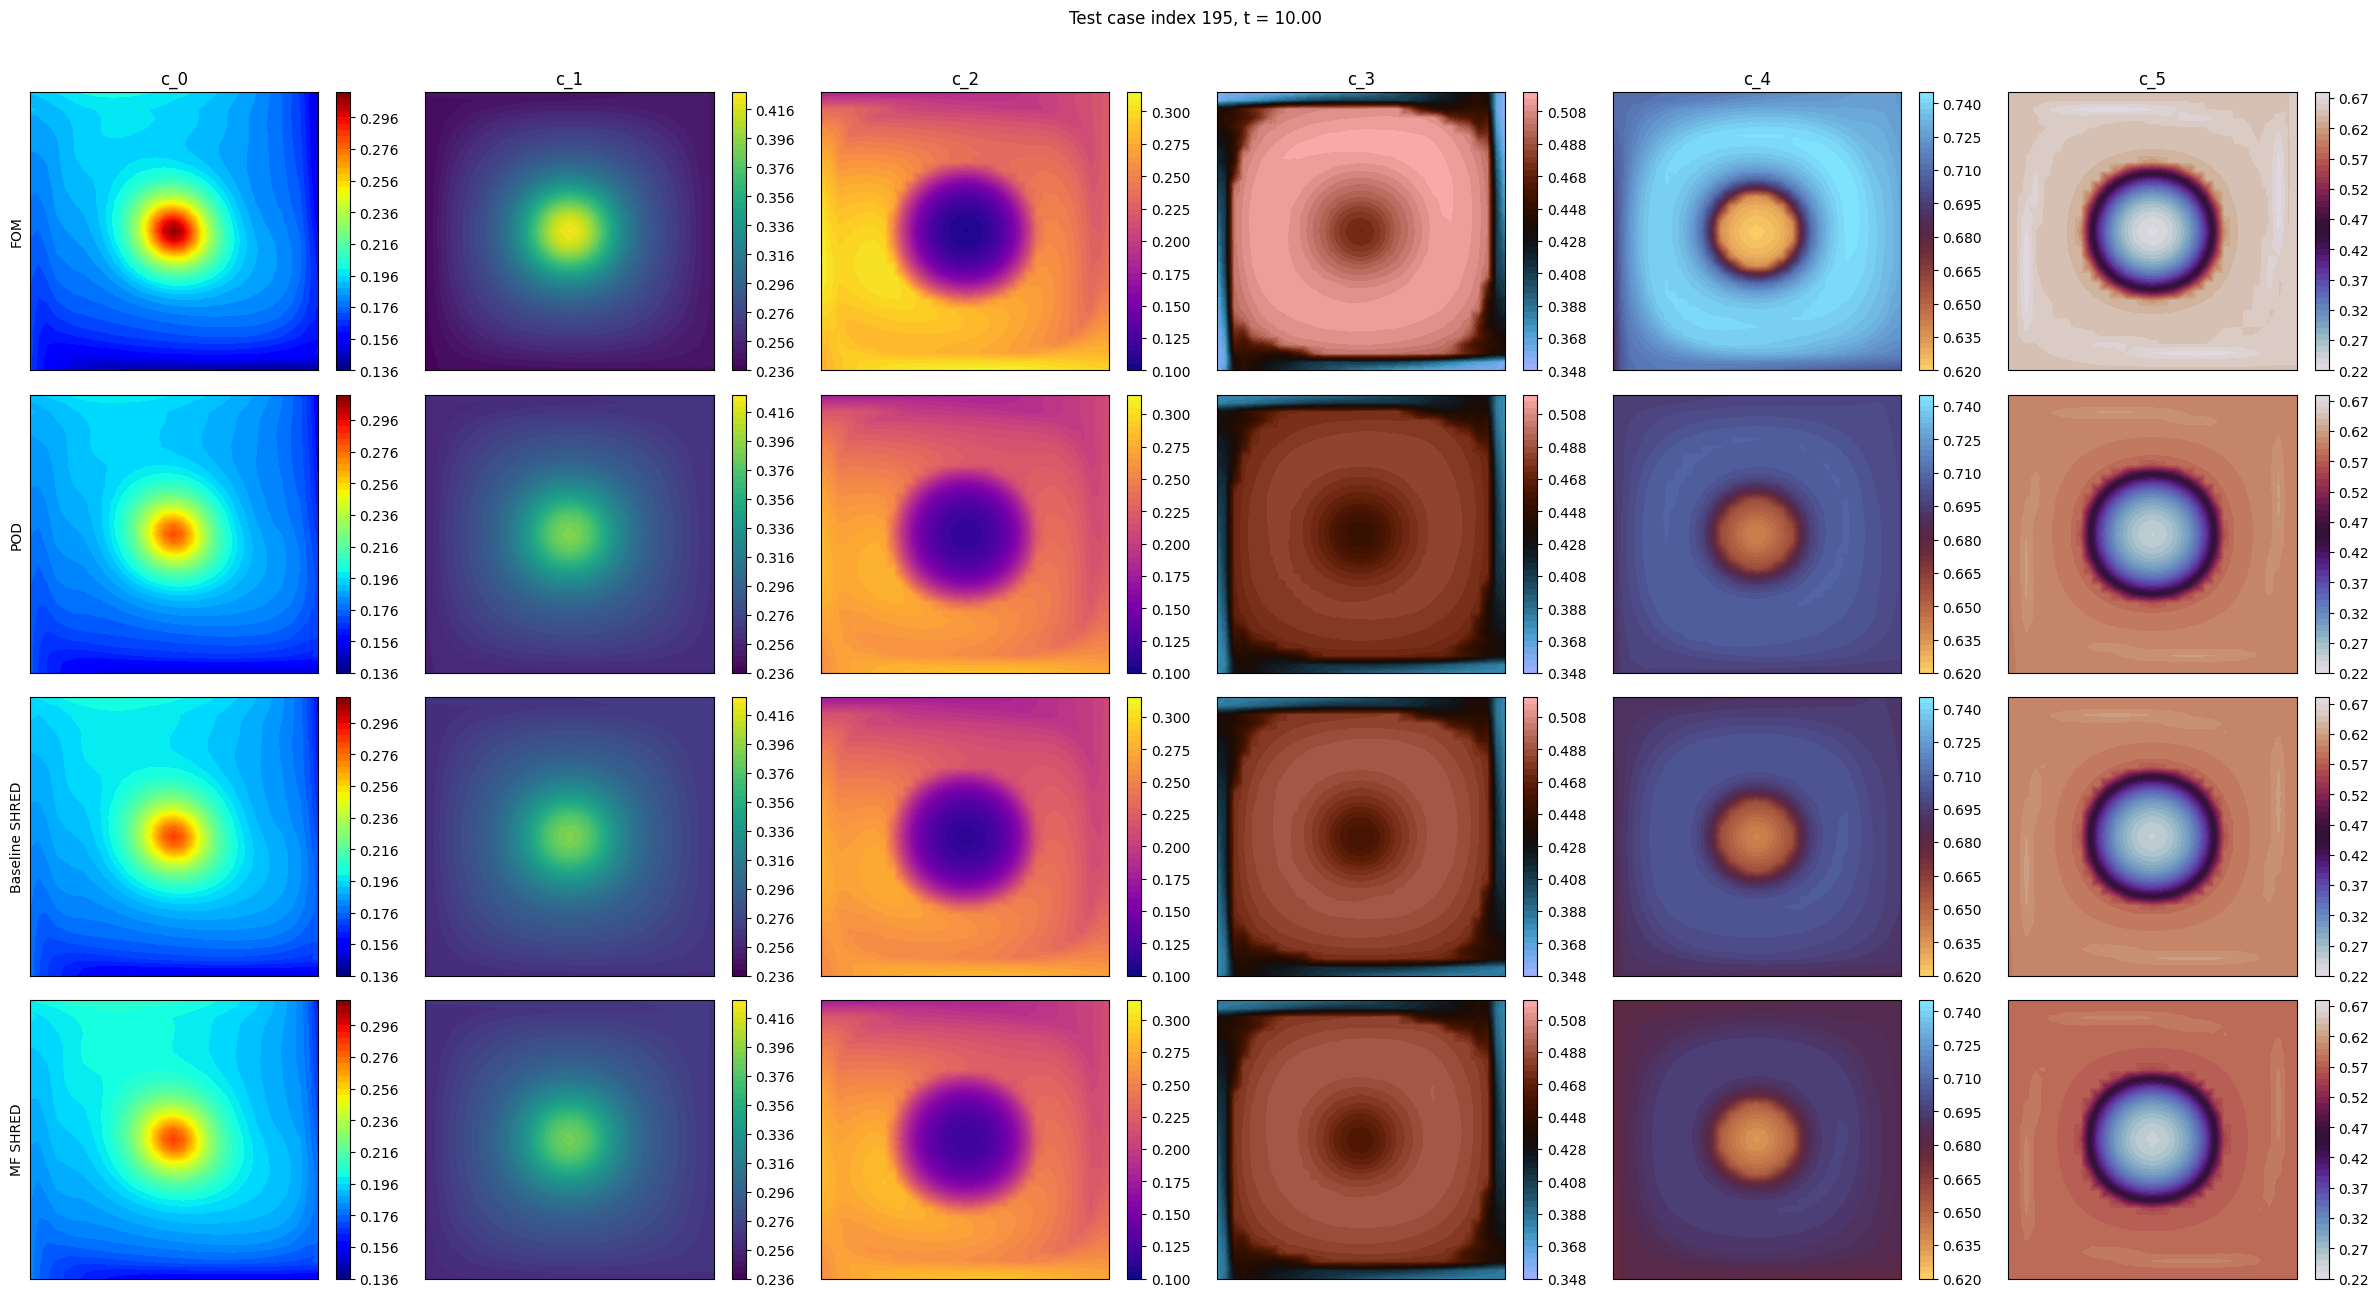

In [36]:
tt = -1
np.random.seed(8)
pp = np.random.randint(0, len(idx_split['test']))

nrows = 4
ncols = num_species
row_labels = ['FOM', 'POD', 'Baseline SHRED', 'MF SHRED']

fig, axs = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.2 * nrows))

for field_i, field in enumerate(var_names):
    _fom = hf_snaps[field][idx_split['test'][pp], tt]
    _idx_pod = np.arange(Nmodes[field_i], Nmodes[field_i + 1])
    _pod_recon = modes[field][:, :ranks[field_i]] @ (modes[field][:, :ranks[field_i]].T @ _fom)
    _baseline_recon = modes[field][:, :ranks[field_i]] @ unscaled_pod_hat[pp, tt, _idx_pod]
    _mf_recon = modes[field][:, :ranks[field_i]] @ unscaled_mf_pod_hat[pp, tt, _idx_pod]

    snapshots = [_fom, _pod_recon, _baseline_recon, _mf_recon]

    c = plotter.plot(axs[0, field_i], _fom, levels=50, cmap=cmaps[field_i])
    fig.colorbar(c, ax=axs[0, field_i])
    levels = np.linspace(c.get_clim()[0] * 0.9, c.get_clim()[1] * 1.1, 50)

    for rr in range(1, nrows):
        plotter.plot(axs[rr, field_i], snapshots[rr], levels=levels, cmap=cmaps[field_i])
        fig.colorbar(c, ax=axs[rr, field_i])

    axs[0, field_i].set_title(f'{field}')

for rr in range(nrows):
    axs[rr, 0].set_ylabel(row_labels[rr])

fig.suptitle(f'Test case index {pp}, t = {times[tt]:.2f}', y=1.01)
plt.tight_layout()
plt.show()

### Spatially averaged trajectories

For several test parameter cases we compare the spatial mean of each species over time: FOM, POD truncation, baseline SHRED, and MF SHRED.

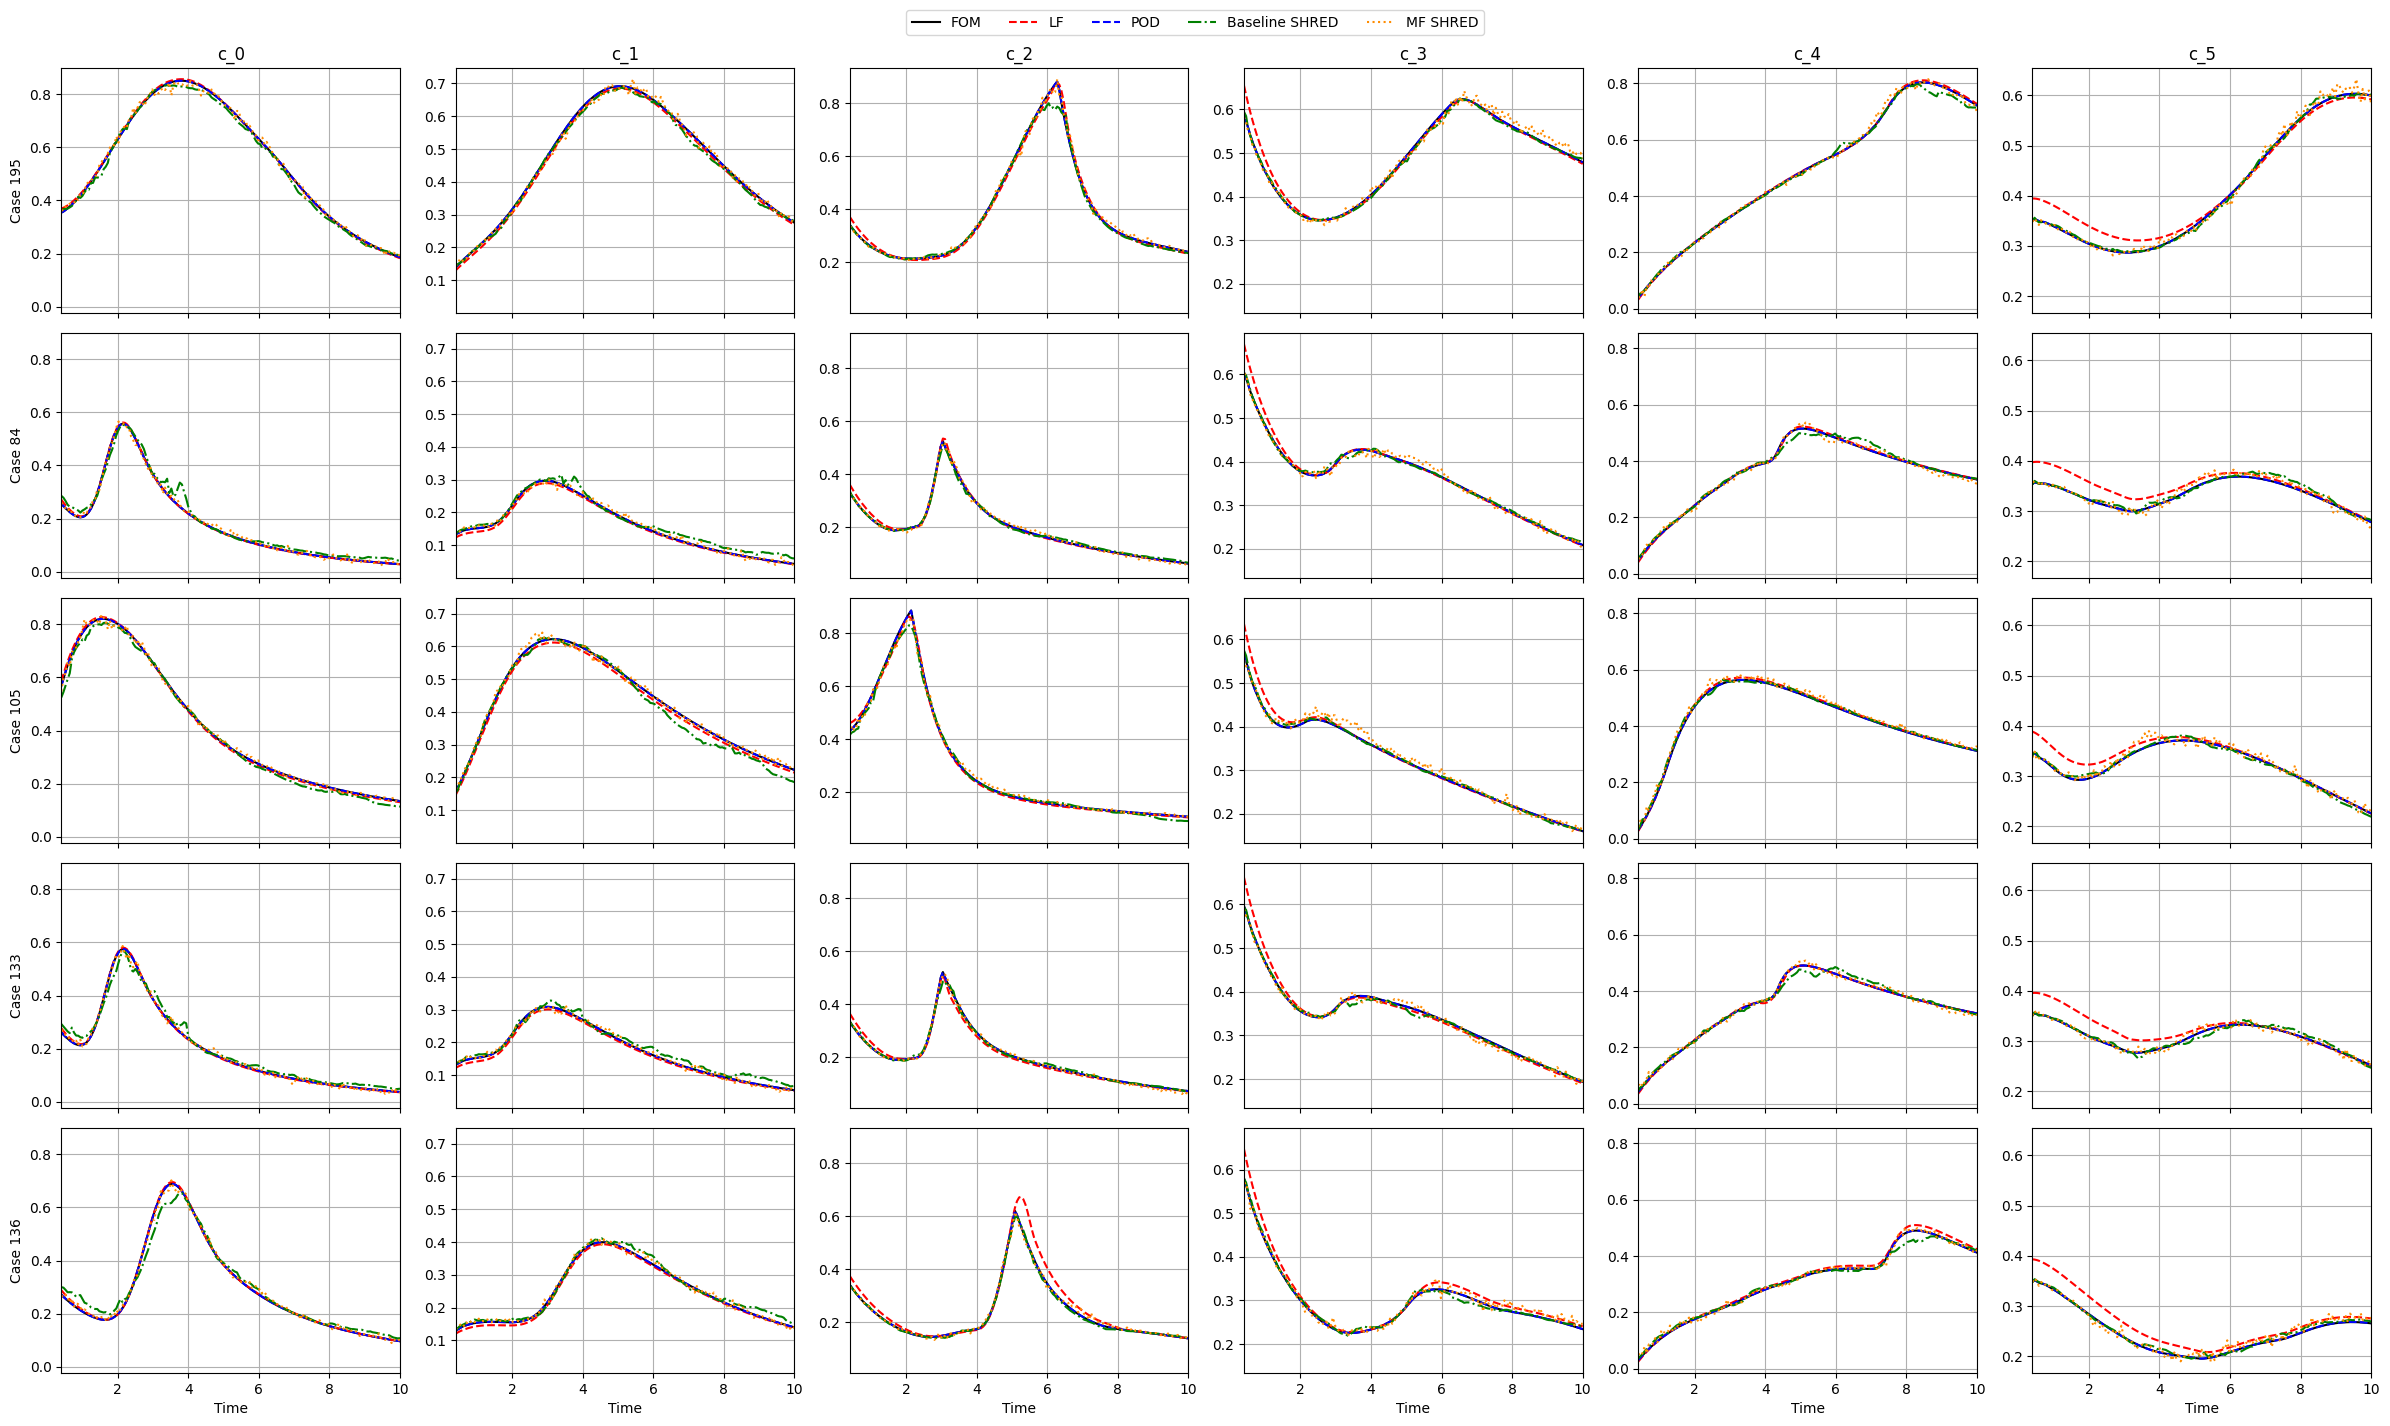

In [37]:
np.random.seed(8)
params_to_plot = np.random.randint(0, len(idx_split['test']), size=5)

nrows = len(params_to_plot)
ncols = num_species

fig, axs = plt.subplots(nrows, ncols, figsize=(4 * ncols, 2.8 * nrows), sharex=True, sharey='col')

for ii, param in enumerate(params_to_plot):
    for field_i, field in enumerate(var_names):
        _fom = hf_snaps[field][idx_split['test'][param], :]
        _pod_recon = (modes[field][:, :ranks[field_i]] @ (modes[field][:, :ranks[field_i]].T @ _fom.T)).mean(axis=0)
        _fom_mean = _fom.mean(axis=-1)

        _idx_pod = np.arange(Nmodes[field_i], Nmodes[field_i + 1])
        _baseline_mean = (modes[field][:, :ranks[field_i]] @ unscaled_pod_hat[param, :, _idx_pod]).mean(axis=0)
        _mf_mean = (modes[field][:, :ranks[field_i]] @ unscaled_mf_pod_hat[param, :, _idx_pod]).mean(axis=0)

        # LF - it has to be scaled
        _lf = lf[idx_split['test'][param], :, field_i] - hf_scalers[field].data_min_.mean()
        _lf /= hf_scalers[field].data_max_.mean() - hf_scalers[field].data_min_.mean()

        axs[ii, field_i].plot(times, _fom_mean, 'k-', label='FOM', lw=1.5)
        axs[ii, field_i].plot(times, _lf, 'r--', label='LF', lw=1.5)
        axs[ii, field_i].plot(times, _pod_recon, 'blue', ls='--', label='POD')
        axs[ii, field_i].plot(times, _baseline_mean, color='green', ls='-.', label='Baseline SHRED')
        axs[ii, field_i].plot(times, _mf_mean, color='darkorange', ls=':', label='MF SHRED')

        axs[ii, field_i].set_xlim(times[0], times[-1])
        axs[ii, field_i].grid()

        if ii == 0:
            axs[ii, field_i].set_title(field)
        if field_i == 0:
            axs[ii, field_i].set_ylabel(f'Case {param}')

        if ii == nrows - 1:
            axs[ii, field_i].set_xlabel('Time')

_lin, _lab = axs[0, 0].get_legend_handles_labels()
fig.legend(_lin, _lab, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncols=5)
plt.tight_layout()
plt.show()

### Computational cost comparison

**Online (left):** mean wall time per parameter trajectory ($N_t$ stored timesteps). Four routes are compared: HF PDE, LF ODE, LF + MF-SHRED with **one** sensor configuration (`Prediction / n_configurations`), and LF + MF-SHRED with the **full ensemble** (`torch.stack` over all configurations). HF and LF error bars show case-to-case variability from dataset generation.

**Offline (right):** one-time setup — total POD randomized SVD time, total MF-SHRED training time, and mean training time per sensor configuration.

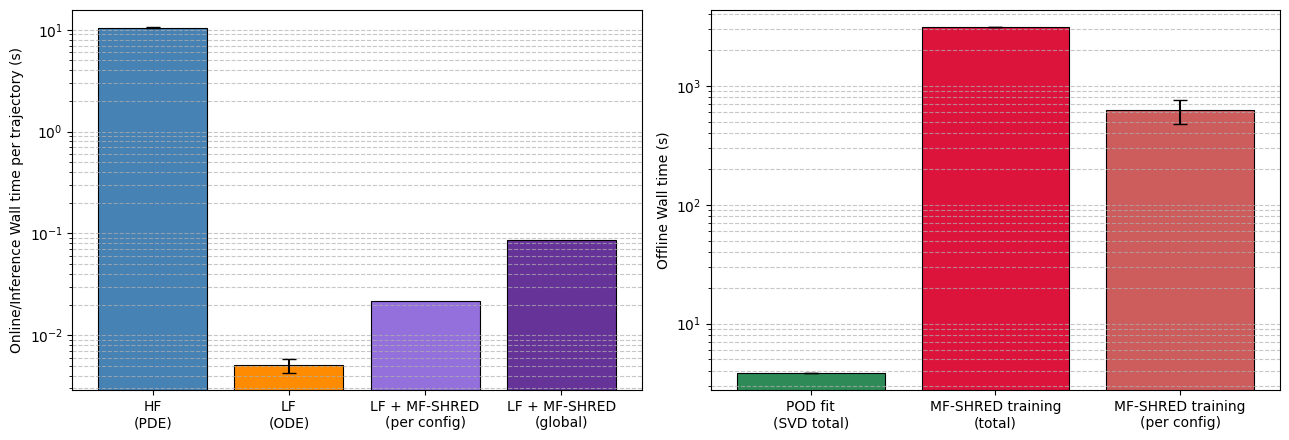

In [ ]:
mf = computational_times['MF-SHRED']
n_test = len(idx_split['test'])

# --- Online: per parameter case (all Nt timesteps) ---
hf_per_case = computational_times['HF-Generation']
lf_per_case = computational_times['LF-Generation']
lf_mean = lf_per_case.mean()

decode_per_case = np.sum(mf['Decode']) / n_test
postprocess_per_case = (mf['Reshape'] + mf['ScaleBack']) / n_test

mf_per_config = mf['Prediction'] / n_configurations / n_test + postprocess_per_case + decode_per_case
mf_global = (mf['Prediction'] + mf['Reshape'] + mf['ScaleBack']) / n_test + decode_per_case

lf_mf_per_config = lf_mean + mf_per_config
lf_mf_global = lf_mean + mf_global

# --- Offline: one-time setup ---
pod_total = np.sum(computational_times['POD-Fit'])
training = np.asarray(mf['Training'])
training_total = training.sum()
training_mean = training.mean()

# --- Plot ---
fig, (ax_on, ax_off) = plt.subplots(1, 2, figsize=(13, 4.5))
bar_kw = dict(edgecolor='k', linewidth=0.8)

# Online: HF, LF, LF+MF (per config), LF+MF (global)
online_labels = [
    'HF\n(PDE)',
    'LF\n(ODE)',
    'LF + MF-SHRED\n(per config)',
    'LF + MF-SHRED\n(global)',
]
online_vals = [hf_per_case.mean(), lf_mean, lf_mf_per_config, lf_mf_global]
online_errs = [hf_per_case.std(), lf_per_case.std(), None, None]
online_colors = ['steelblue', 'darkorange', 'mediumpurple', 'rebeccapurple']

for i, (val, err, color) in enumerate(zip(online_vals, online_errs, online_colors)):
    ax_on.bar(
        i, val,
        yerr=err,
        capsize=5 if err is not None else 0,
        color=color,
        **bar_kw,
    )

ax_on.set_xticks(np.arange(4))
ax_on.set_xticklabels(online_labels)
ax_on.set_ylabel('Online/Inference Wall time per trajectory (s)')

# Offline: POD total, training total, training mean per config
offline_labels = [
    'POD fit\n(SVD total)',
    'MF-SHRED training\n(total)',
    'MF-SHRED training\n(per config)',
]
offline_vals = [pod_total, training_total, training_mean]
offline_errs = [np.std(computational_times['POD-Fit']), 0, training.std()]
offline_colors = ['seagreen', 'crimson', 'indianred']

ax_off.bar(
    np.arange(3),
    offline_vals,
    yerr=offline_errs,
    capsize=5,
    color=offline_colors,
    **bar_kw,
)
ax_off.set_xticks(np.arange(3))
ax_off.set_xticklabels(offline_labels)
ax_off.set_ylabel('Offline Wall time (s)')

for ax in ax_on, ax_off:
    ax.set_yscale('log')
    ax.grid(axis='y', which='both', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()